In [2]:
import pandas as pd  # For data manipulation
import matplotlib.pyplot as plt  # For plotting
import seaborn as sns  # For advanced visualization
import scipy.stats as stats  # For statistical functions

# Load the Excel file
file_path = 'FINAL-ADSAI-knowledge_September 30, 2024_16.35.xlsx'
excel_data = pd.ExcelFile(file_path)  # Reads the entire Excel file

# Check all sheet names (good for ensuring the correct sheet is chosen)
sheet_names = excel_data.sheet_names
print(sheet_names)  # Optional: Print sheet names to verify they were read correctly

# Load the specific sheet into a DataFrame (in this case, 'in')
data = pd.read_excel(excel_data, sheet_name='in')

# Display the first 5 rows to check if data is loaded correctly
data.head()

['in']


,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,Q28,Q29,Q30,Q31,Q32,Q33,Q33_4_TEXT,Q34,Q35,PROLIFIC_PID
0,Start Date,End Date,Response Type,IP Address,Progress,Duration (in seconds),Finished,Recorded Date,Response ID,Recipient Last Name,...,Which industry does your company operate in?,What is your role or department in the company?,What is the size of your company?,What is your company's annual revenue?,List of Countries,How do you describe yourself? - Selected Choice,How do you describe yourself? - Prefer to self...,What is the highest level of education you hav...,How old are you?,PROLIFIC_PID
1,"{""ImportId"":""startDate"",""timeZone"":""Europe/Ber...","{""ImportId"":""endDate"",""timeZone"":""Europe/Berlin""}","{""ImportId"":""status""}","{""ImportId"":""ipAddress""}","{""ImportId"":""progress""}","{""ImportId"":""duration""}","{""ImportId"":""finished""}","{""ImportId"":""recordedDate"",""timeZone"":""Europe/...","{""ImportId"":""_recordId""}","{""ImportId"":""recipientLastName""}",...,"{""ImportId"":""QID56""}","{""ImportId"":""QID57""}","{""ImportId"":""QID45""}","{""ImportId"":""QID5""}","{""ImportId"":""QID35""}","{""ImportId"":""QID24""}","{""ImportId"":""QID24_4_TEXT""}","{""ImportId"":""QID8""}","{""ImportId"":""QID53""}","{""ImportId"":""PROLIFIC_PID""}"
2,2024-09-30 15:25:55,2024-09-30 15:26:57,Survey Preview,NaN,100,61,true,2024-09-30 15:26:57,R_8ROpmDdiy6hYKAd,NaN,...,Healthcare and Pharmaceuticals,Operations,Fewer than 5 employees,â‚¬1 million to â‚¬5 million,Armenia,Male,NaN,Less than high school,25-34 years old,NaN
3,2024-09-30 15:34:16,2024-09-30 15:36:38,IP Address,5.146.132.253,100,141,true,2024-09-30 15:36:39,R_2lnmn9ItoIScqBw,NaN,...,Finance and Insurance,Administrative,More than 250 employees,I do not know,Germany,Male,NaN,High school diploma or equivalent,55-64 years old,6605c195e4727703228ef777
4,2024-09-30 15:33:56,2024-09-30 15:36:42,IP Address,213.81.156.126,100,166,true,2024-09-30 15:36:42,R_8hAWYwXpiTglZvR,NaN,...,Scientific or Technical Services,IT & Technical Support,More than 250 employees,â‚¬10 million to â‚¬50 million,Slovakia,Female,NaN,Bachelor's degree,25-34 years old,663ad1e9c4066faf455c913d


In [3]:
data.columns

Index(['StartDate', 'EndDate', 'Status', 'IPAddress', 'Progress',
       'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId',
       'RecipientLastName', 'RecipientFirstName', 'RecipientEmail',
       'ExternalReference', 'LocationLatitude', 'LocationLongitude',
       'DistributionChannel', 'UserLanguage', 'Q2', 'Prolific-ID', 'Q3', 'Q4',
       'Q5_1', 'Q5_2', 'Q5_7', 'Q6', 'Q7', 'Q8', 'Q9', 'Q9_9_TEXT', 'Q10',
       'Q10_11_TEXT', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q15_7_TEXT', 'Q16',
       'Q16_9_TEXT', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q23', 'Q24', 'Q25',
       'Q26', 'Q27', 'Q28', 'Q29', 'Q30', 'Q31', 'Q32', 'Q33', 'Q33_4_TEXT',
       'Q34', 'Q35', 'PROLIFIC_PID'],
      dtype='object')

In [4]:
for col in ['Q2', 'Q3', 'Q4', 'Q5_1', 'Q5_2', 'Q5_7', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10']:
    print(f"Unique values in {col}:")
    print(data[col].unique(), "\n")

Unique values in Q2:
['I have read and understood the information above and I agree to voluntary participate in this study.'
 '{"ImportId":"QID33"}' 'Yes' 'No'] 

Unique values in Q3:
['How would you describe your current knowledge of AI?'
 '{"ImportId":"QID50"}' "I am aware of AI but I haven't used any AI tools"
 'I have no knowledge of AI'
 'I can use AI tools such as ChatGPT, but I cannot code'
 'I can use AI tools via APIs such as the OpenAI API, by writing code but I cannot develop models'
 nan
 'I can develop AI models using Tensorflow, PyTorch or other programming frameworks'] 

Unique values in Q4:
['Are you using generative AI tools like ChatGPT outside of work?'
 '{"ImportId":"QID51"}' 'Yes, I have used them occasionally.'
 'Yes, I use them regularly.' 'Rarely' 'No, I have not used them.' nan] 

Unique values in Q5_1:
['How familiar are you with the following generative AI tools? - Text generation (ChatGPT, Gemini, Claude)'
 '{"ImportId":"QID26_1"}' 5 8 7 9 6 10 0 3 2 nan 4] 

In [5]:
# Select columns that start with 'Q'
q_columns = [col for col in data.columns if col.startswith('Q')]

# Create a new DataFrame with only the 'Q' columns
data_questions = data[q_columns]

# Display the first 5 rows of the new DataFrame
print(data_questions.head())


                                                  Q2  \
0  I have read and understood the information abo...   
1                               {"ImportId":"QID33"}   
2                                                Yes   
3                                                Yes   
4                                                Yes   

                                                  Q3  \
0  How would you describe your current knowledge ...   
1                               {"ImportId":"QID50"}   
2   I am aware of AI but I haven't used any AI tools   
3                          I have no knowledge of AI   
4  I can use AI tools such as ChatGPT, but I cann...   

                                                  Q4  \
0  Are you using generative AI tools like ChatGPT...   
1                               {"ImportId":"QID51"}   
2                Yes, I have used them occasionally.   
3                         Yes, I use them regularly.   
4                Yes, I have used them occasio

C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\377606045.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_Q4, order=data_Q4.value_counts().index, palette='viridis')


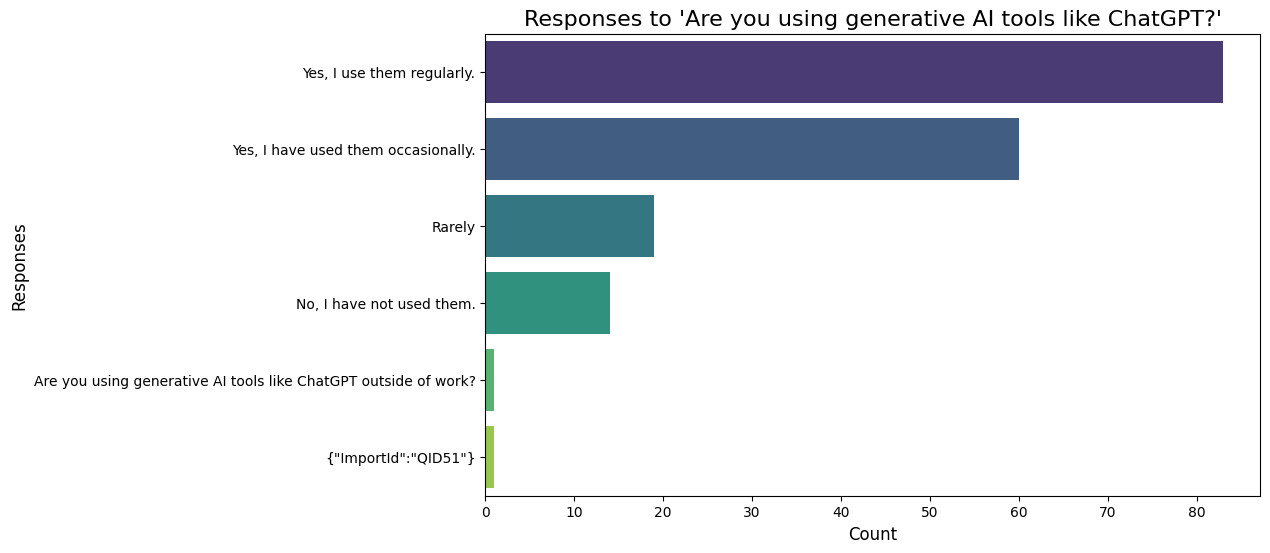

In [6]:
# Check for missing values and clean the data
data_Q4 = data['Q4'].dropna()  # Drop any missing values

plt.figure(figsize=(10, 6))
sns.countplot(y=data_Q4, order=data_Q4.value_counts().index, palette='viridis')

# Adjust the title and labels for better readability
plt.title("Responses to 'Are you using generative AI tools like ChatGPT?'", fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Responses', fontsize=12)

# Optional: Rotate y-axis labels if they are too long
plt.yticks(fontsize=10)

plt.show()

Q2


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


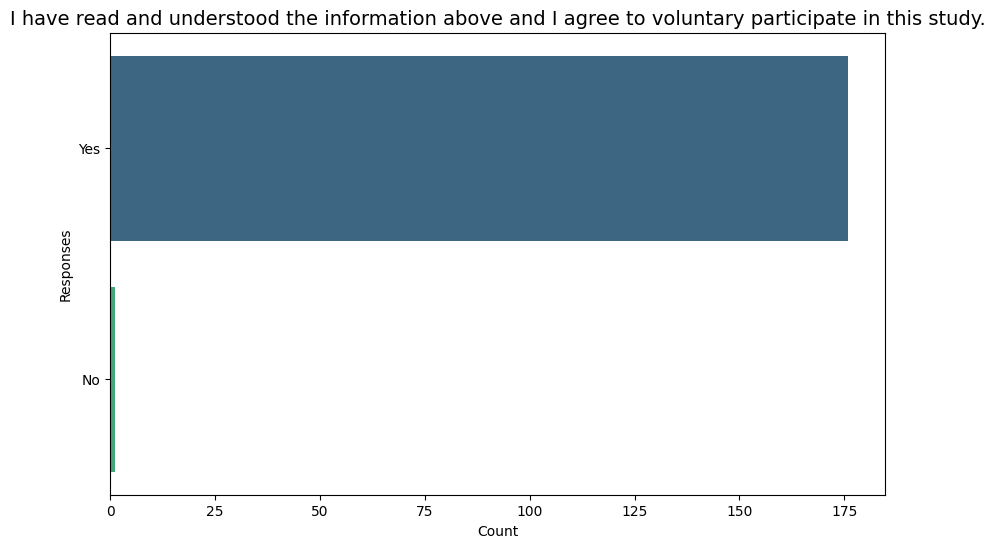

Q3


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


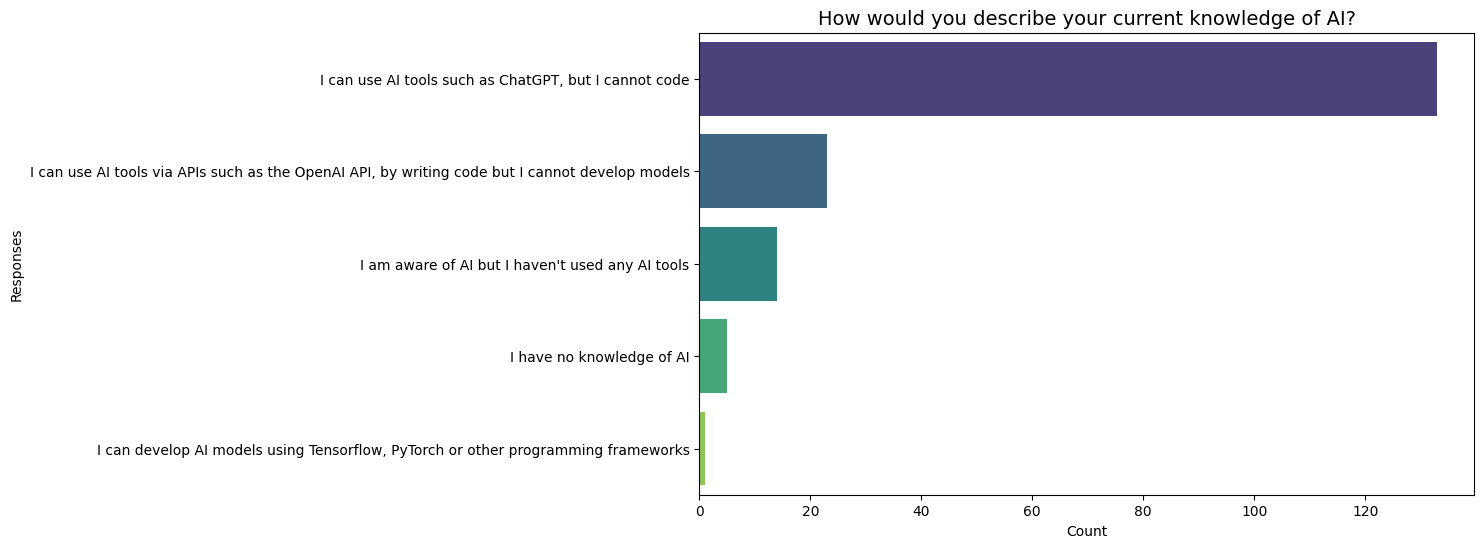

C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


Q4


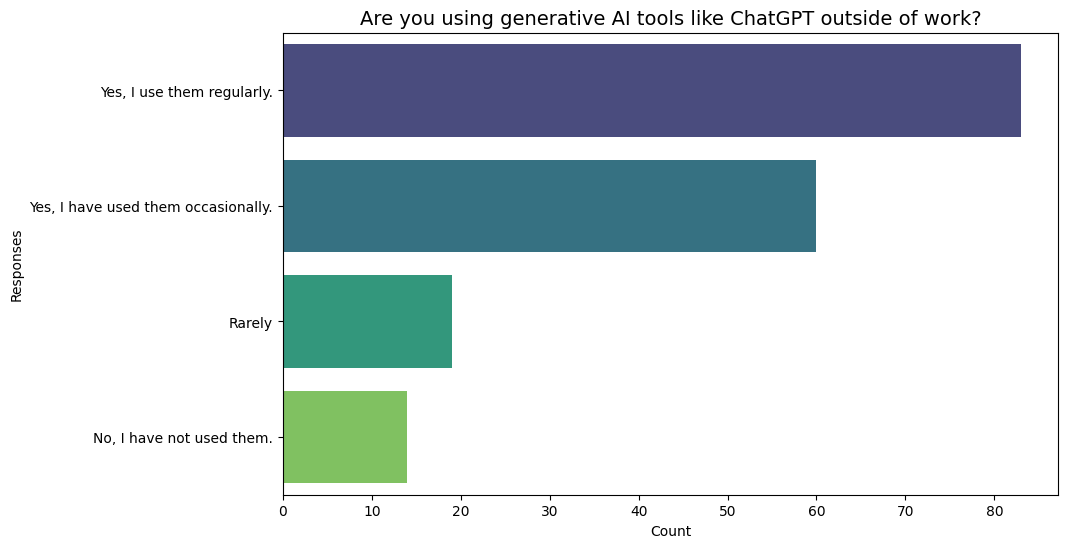

Q5_1


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


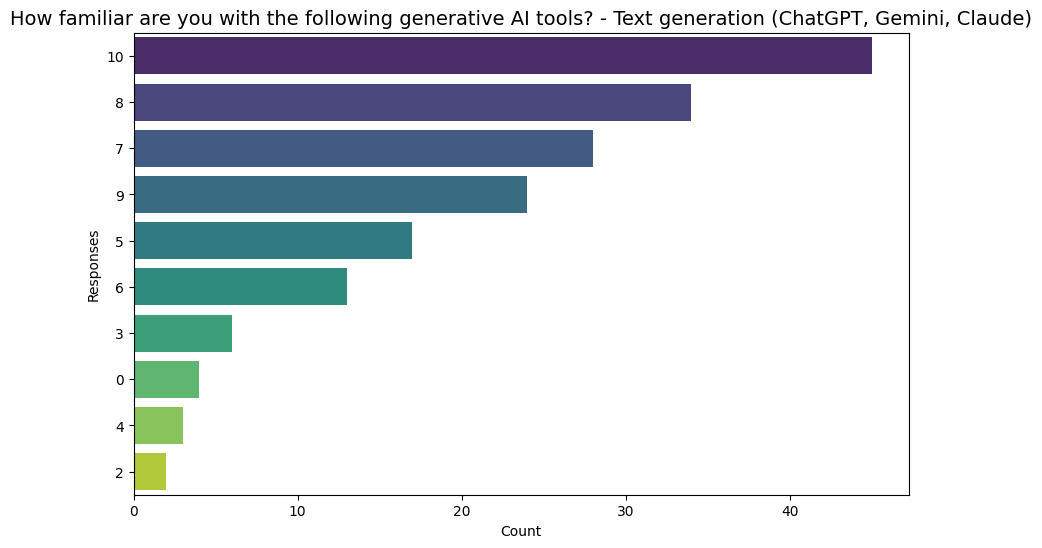

Q5_2


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


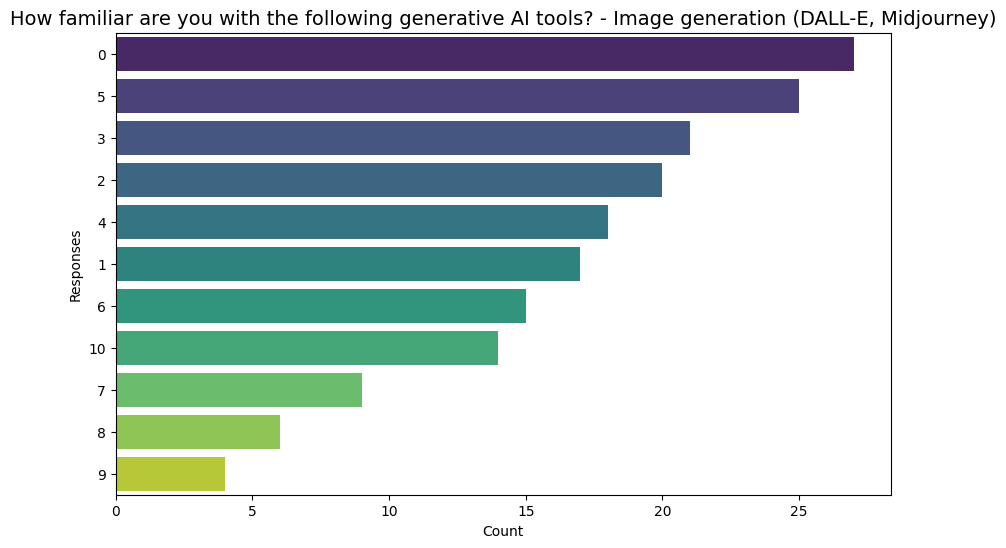

Q5_7


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


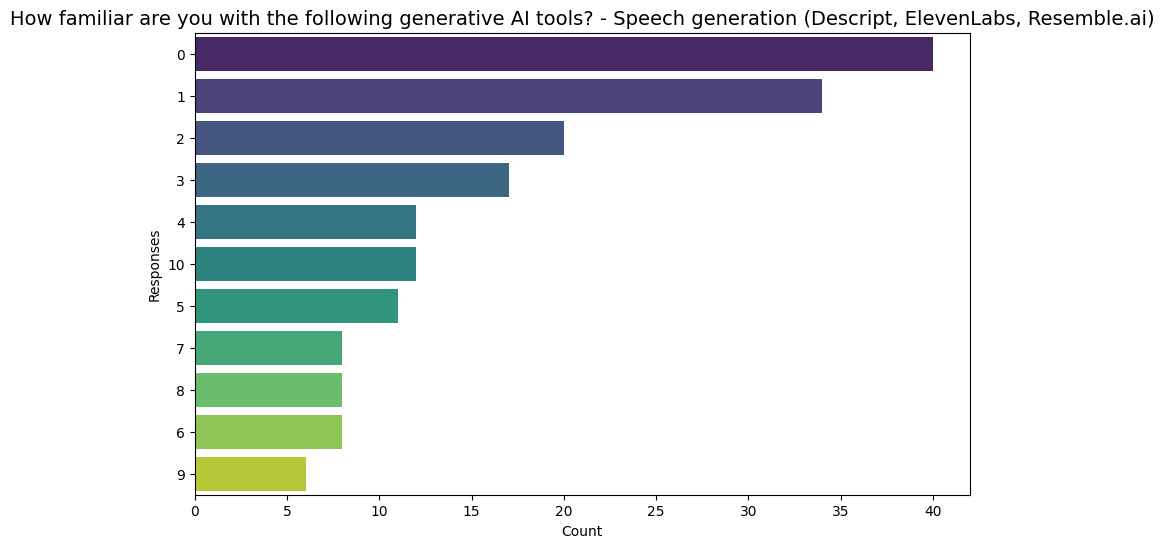

Q6


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


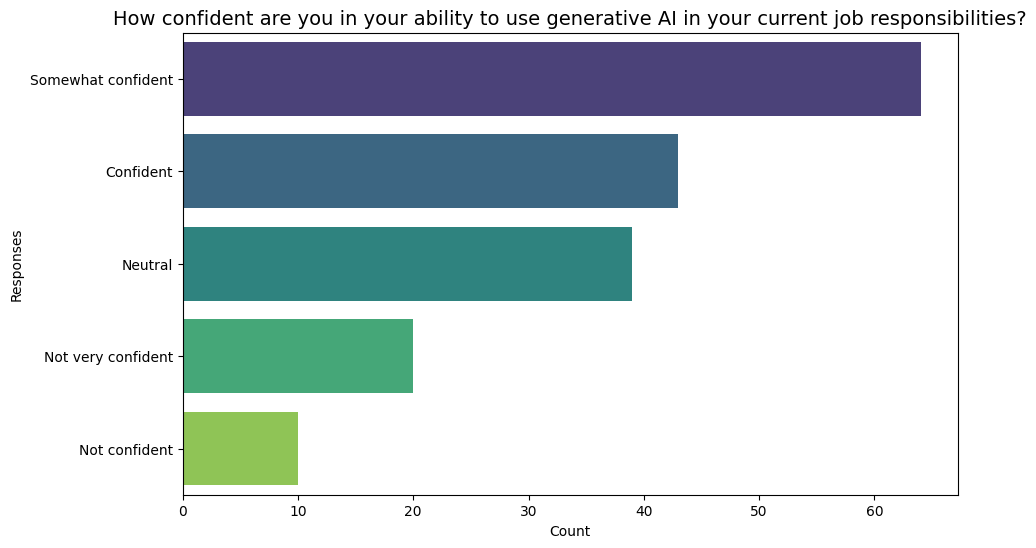

Q7


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


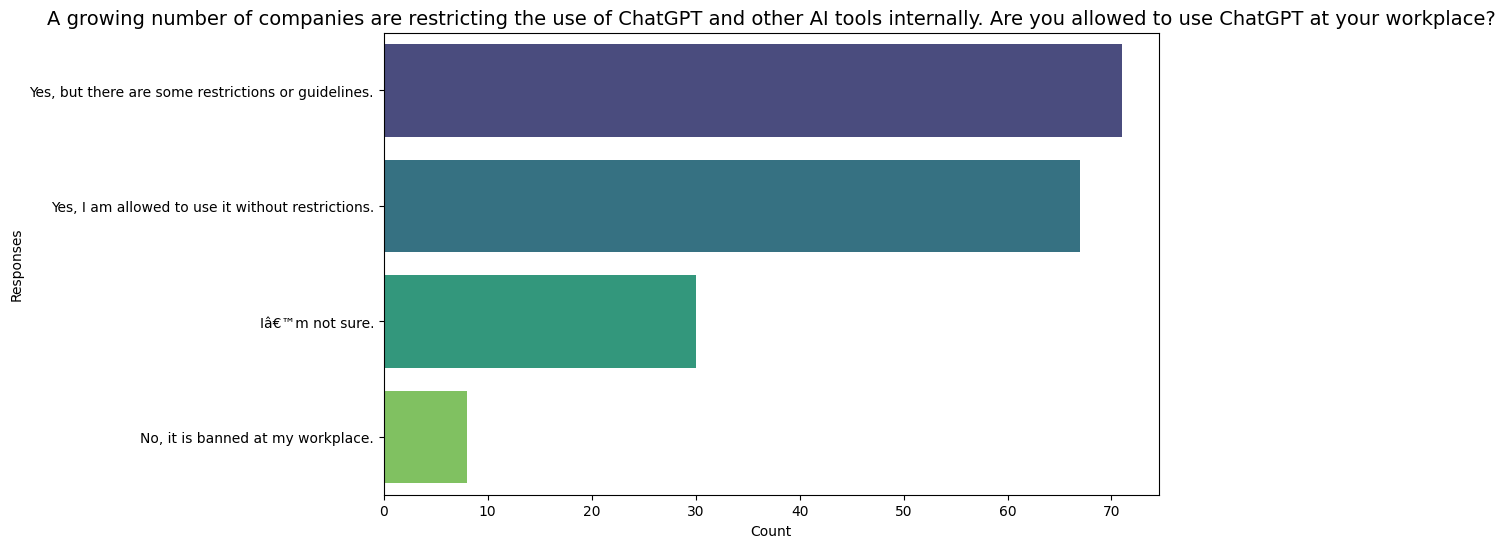

C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


Q8


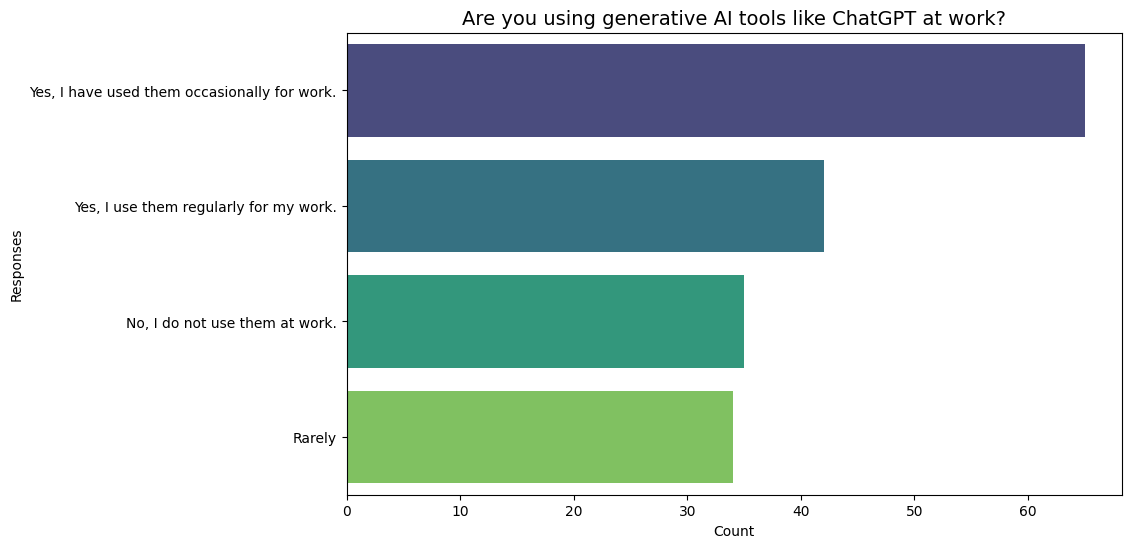

Q9


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


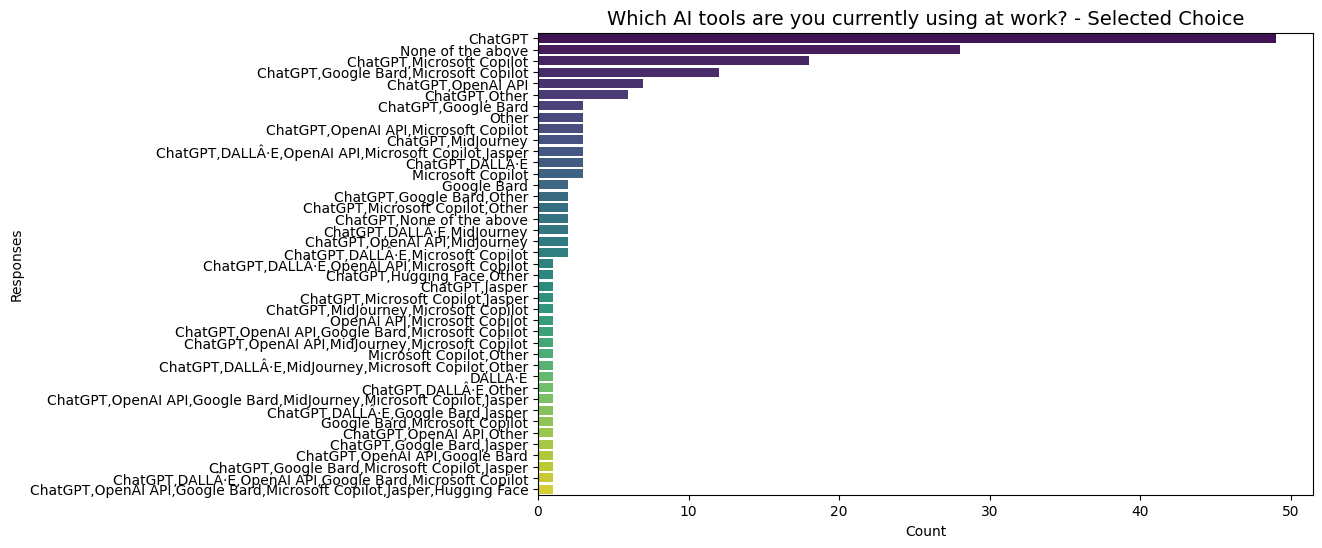

Q9_9_TEXT


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


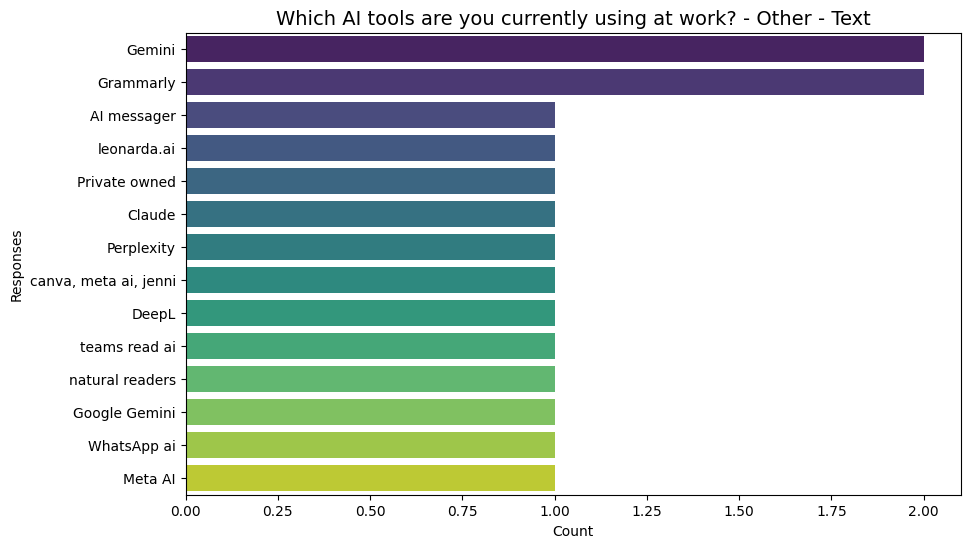

Q10


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


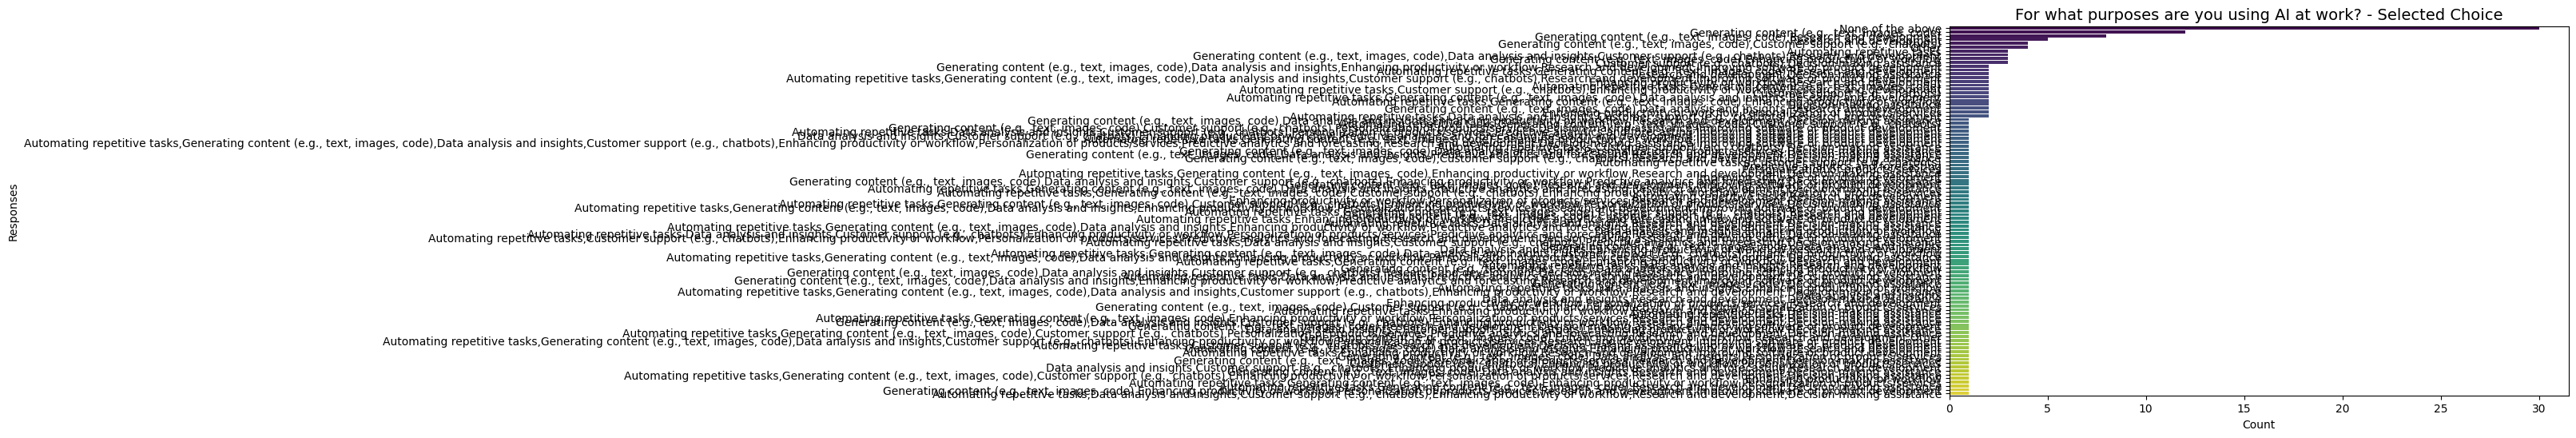

Q10_11_TEXT


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


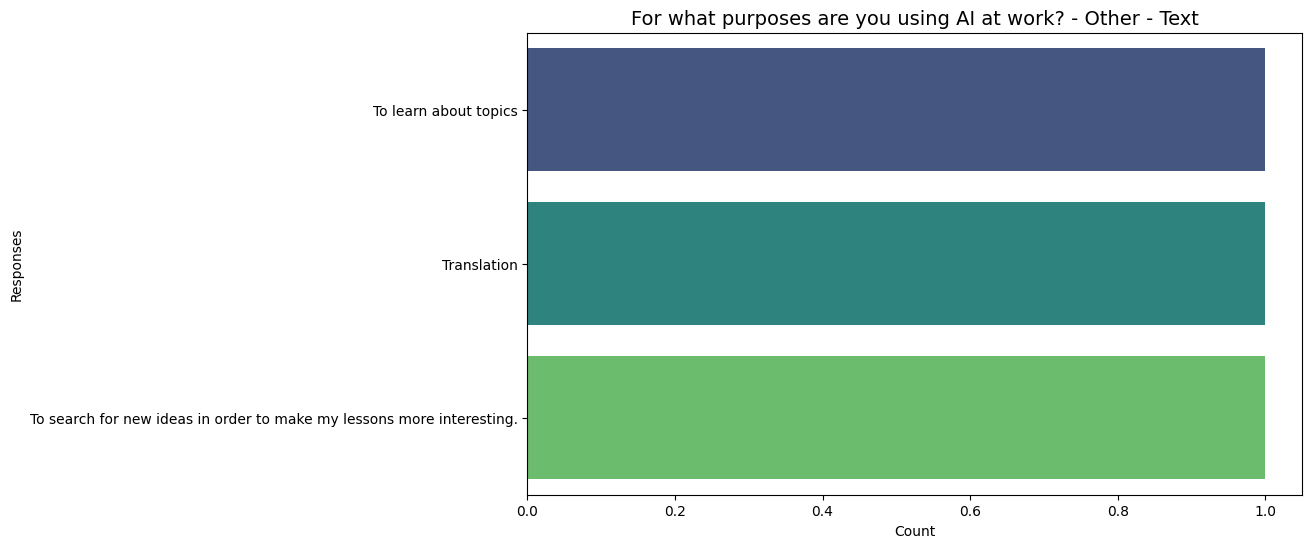

Q11


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


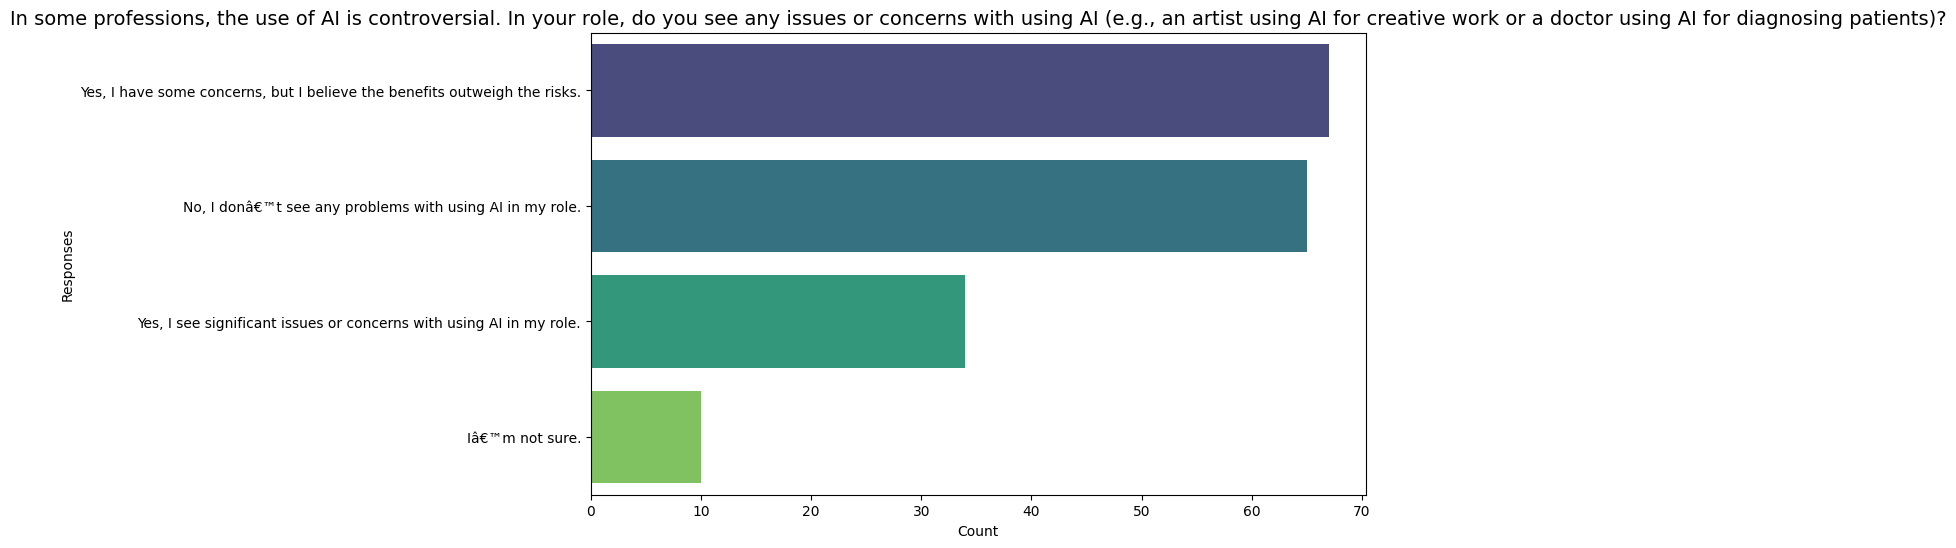

Q12


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


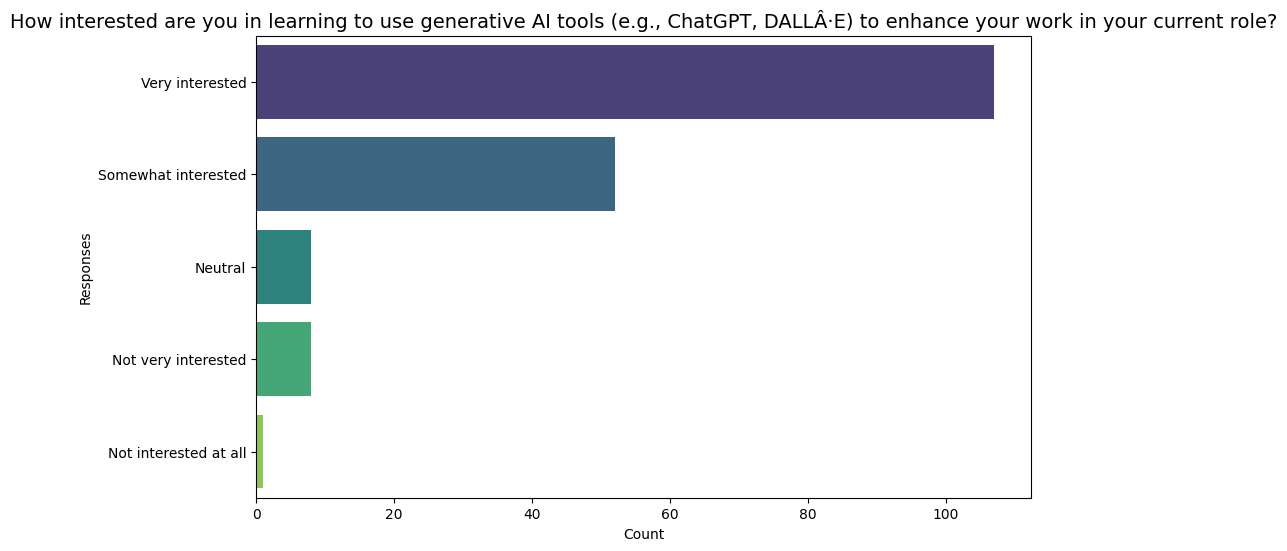

Q13


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


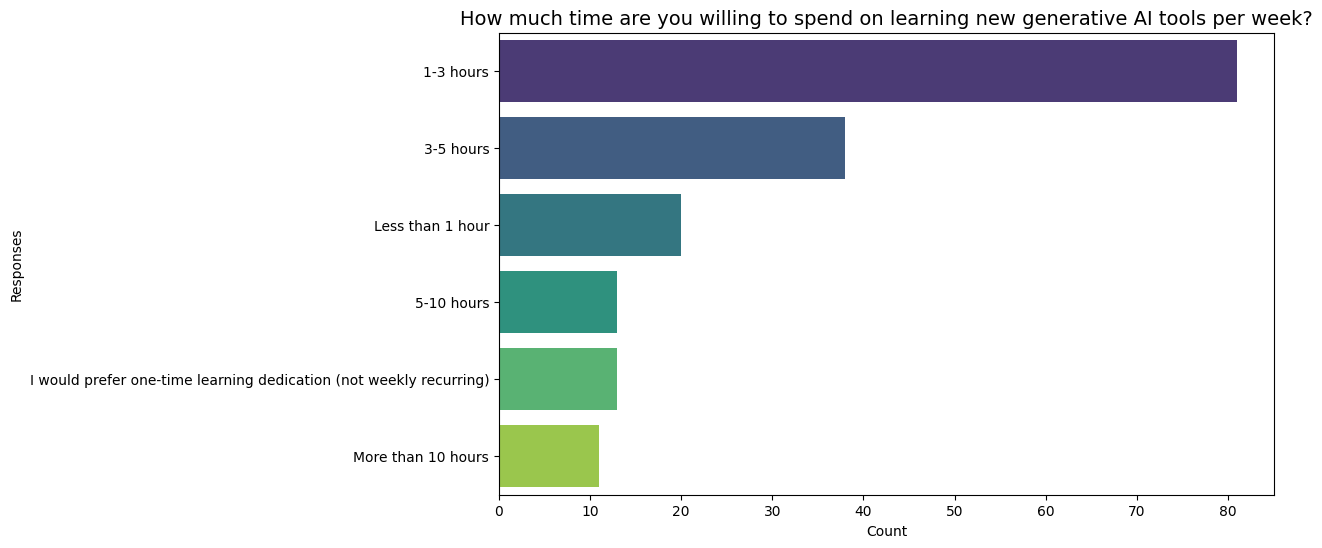

Q14


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


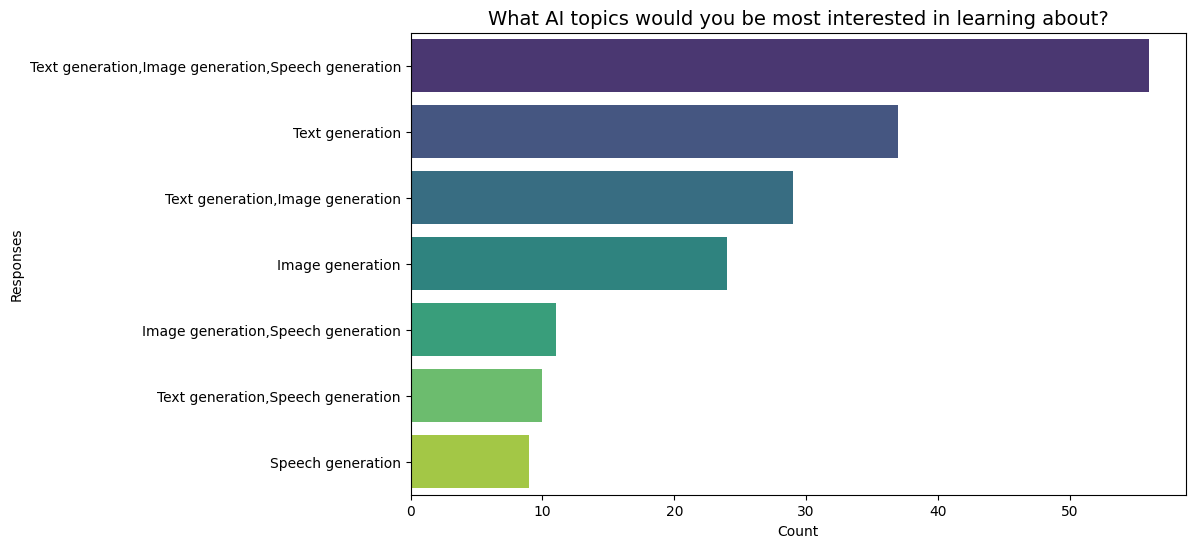

Q15


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


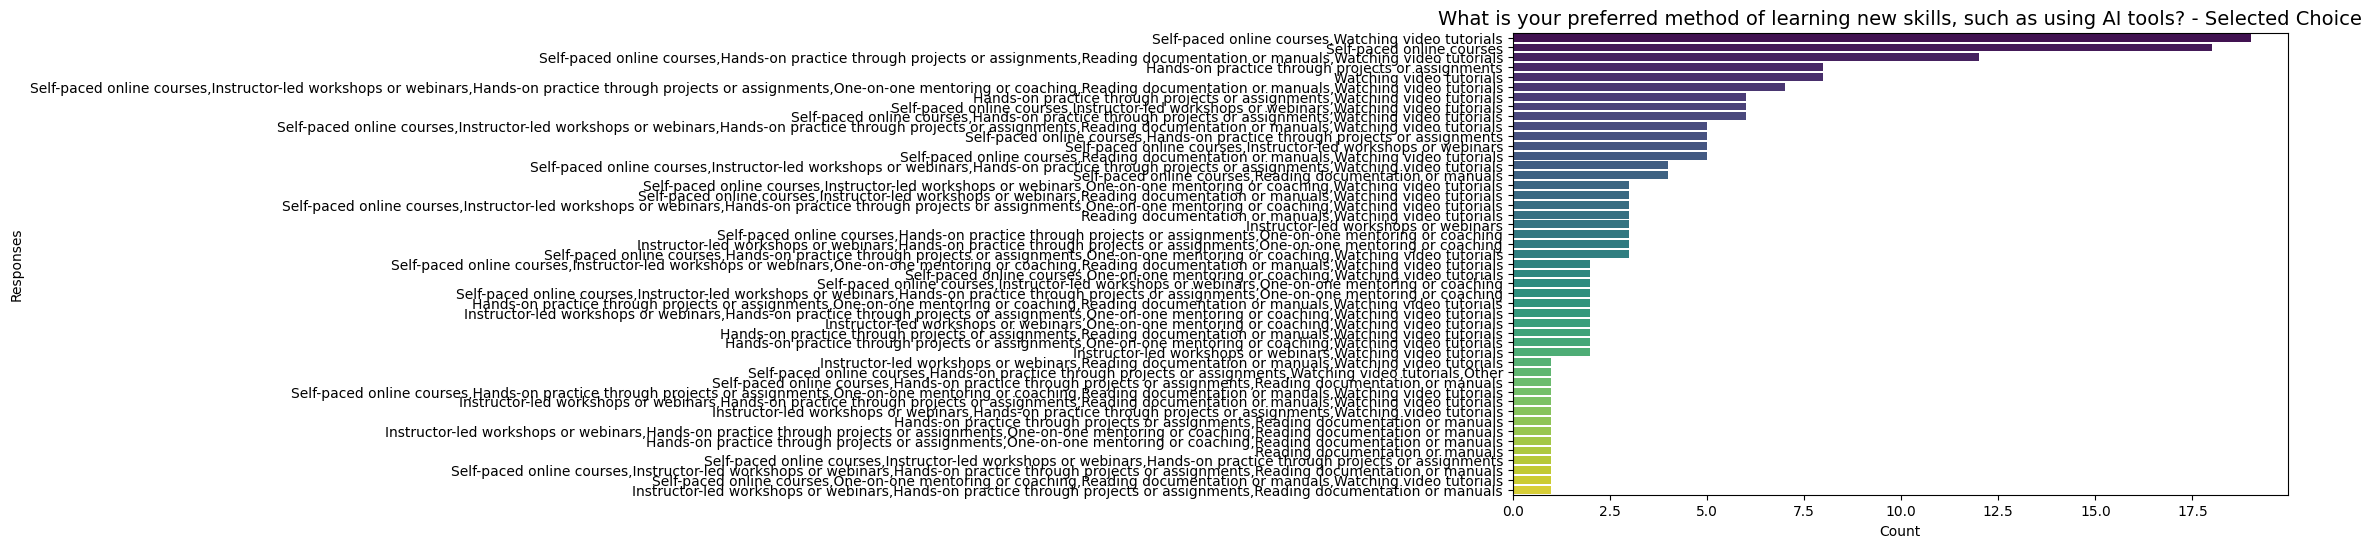

Q15_7_TEXT


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


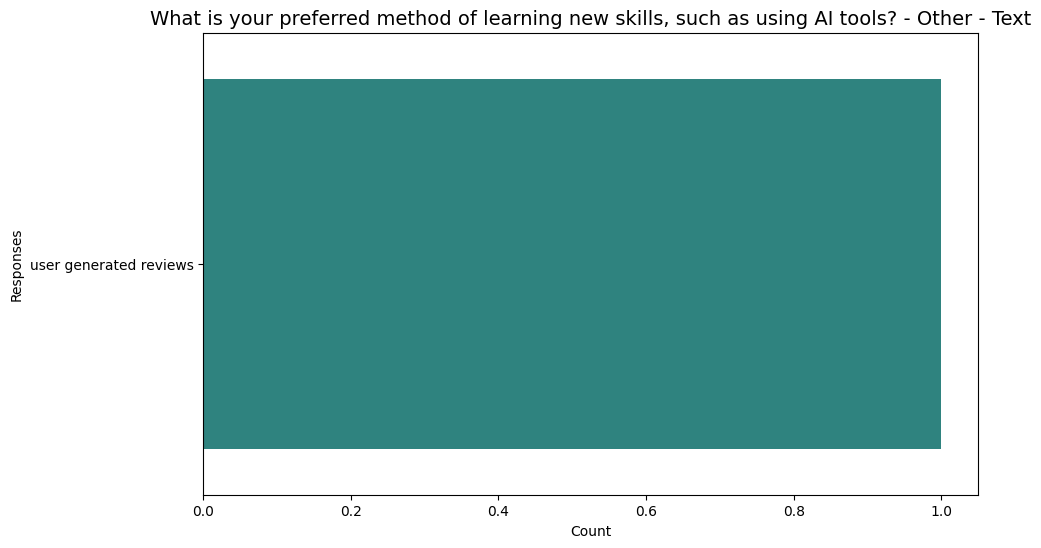

Q16


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


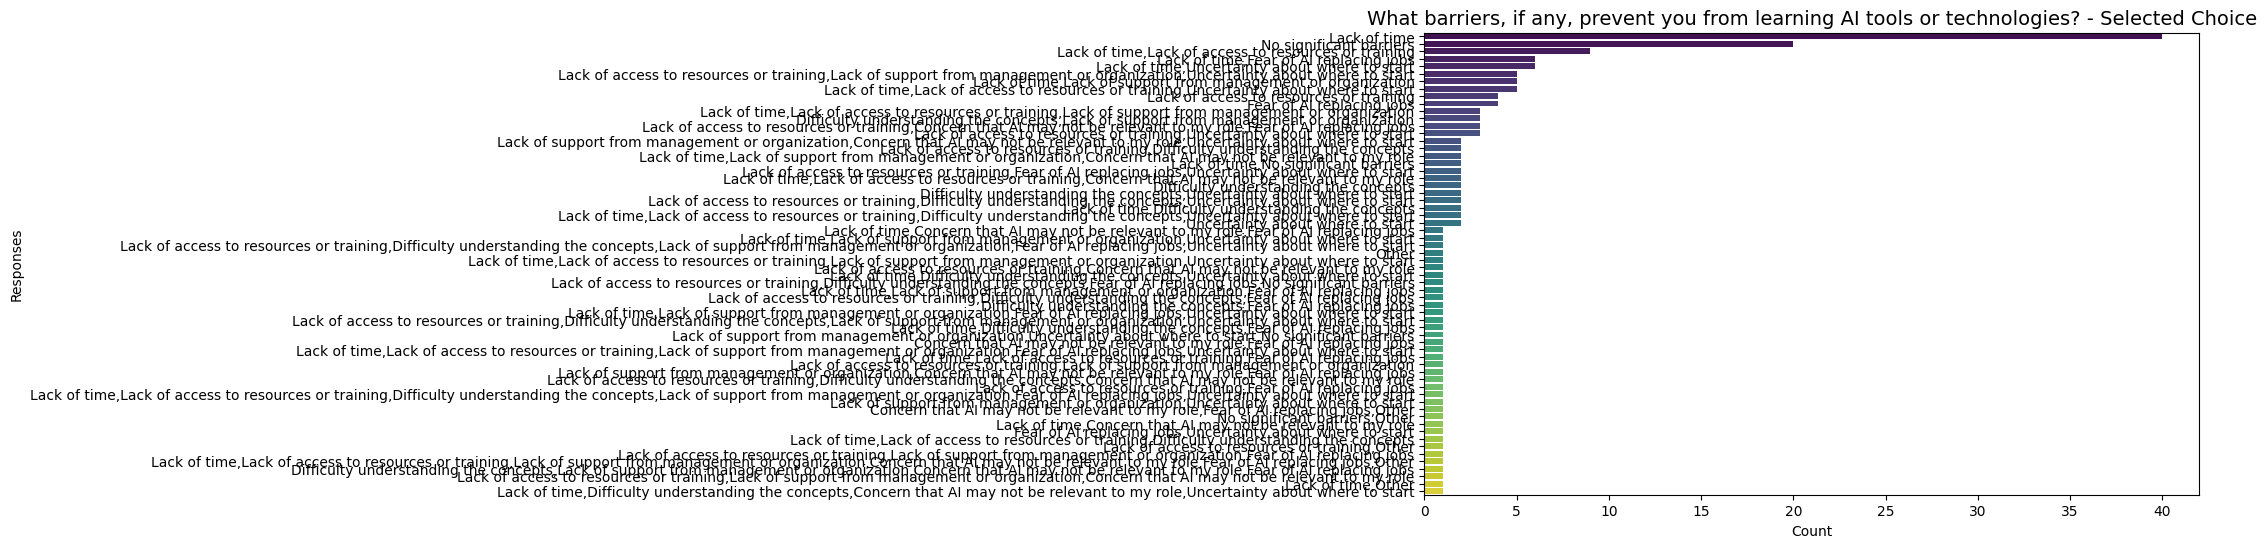

Q16_9_TEXT


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


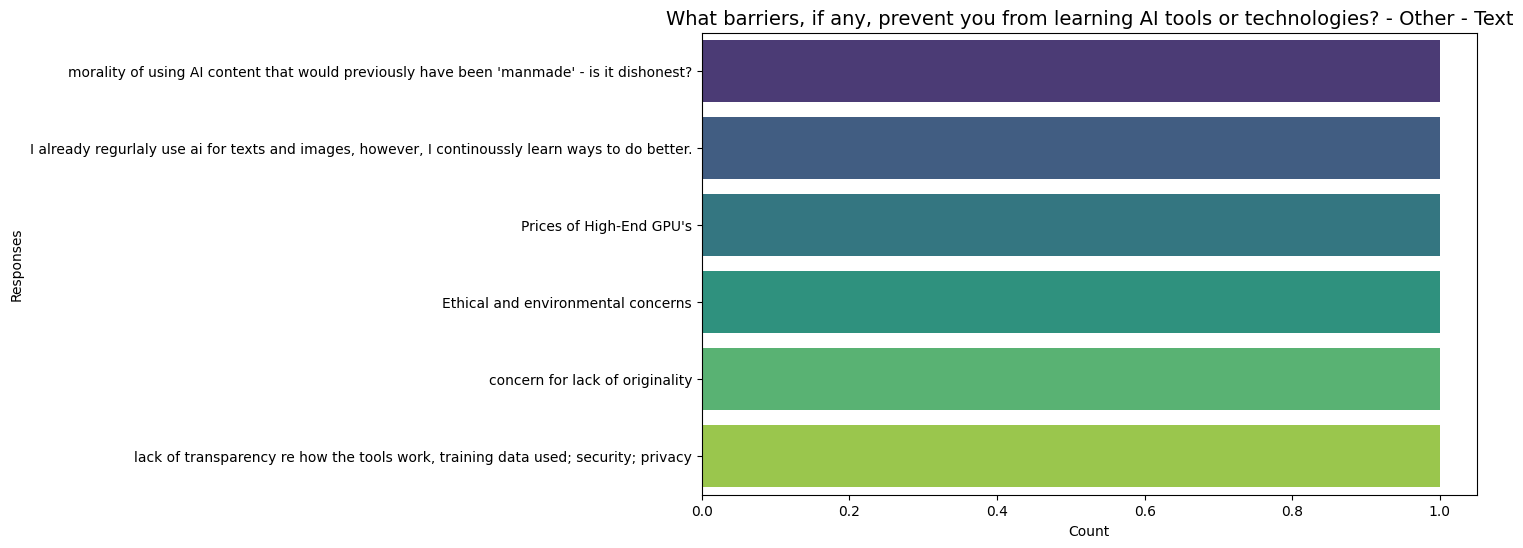

Q17


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


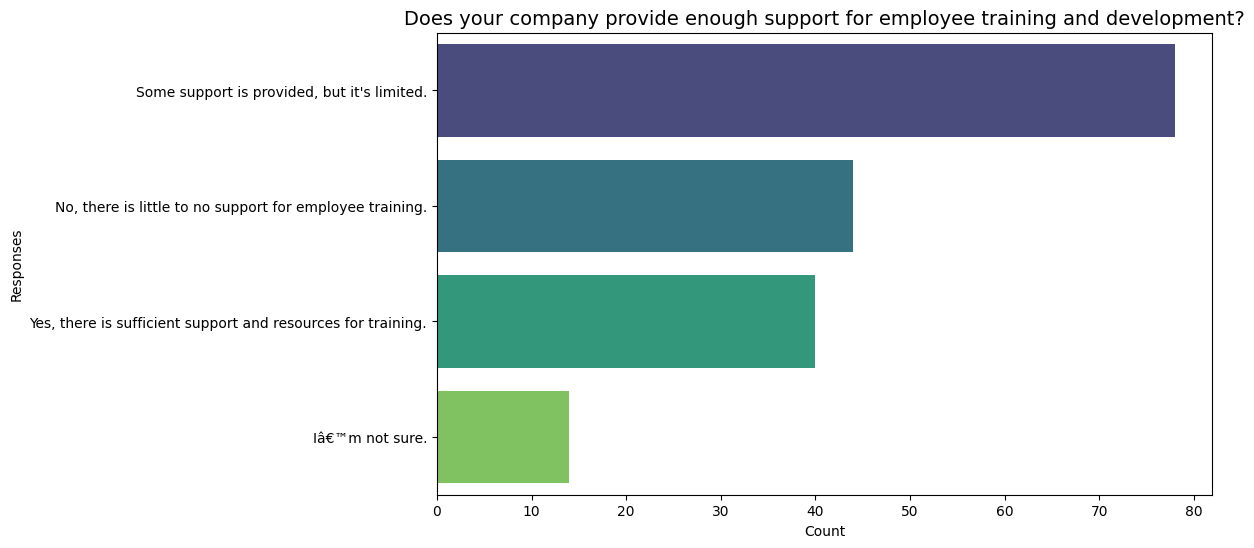

Q18


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


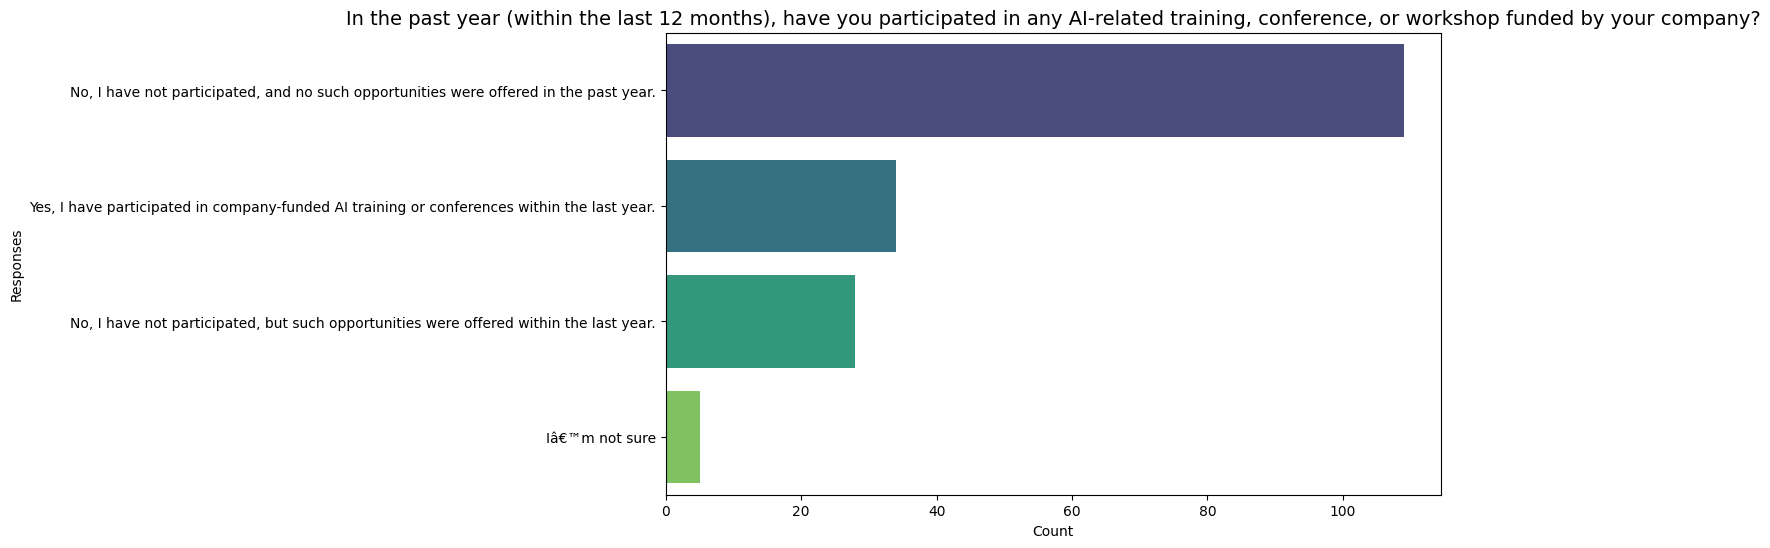

Q19


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


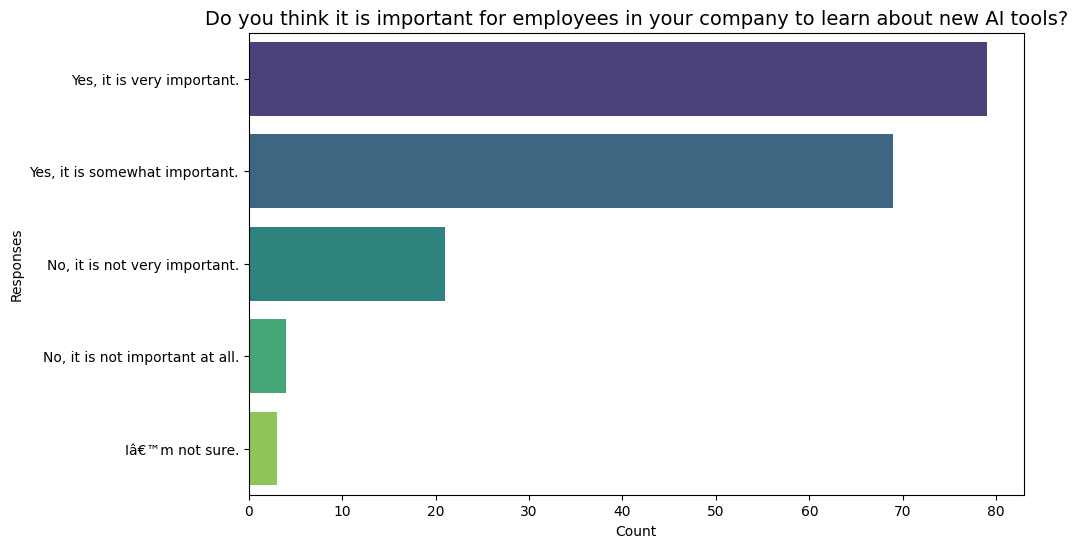

Q20


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


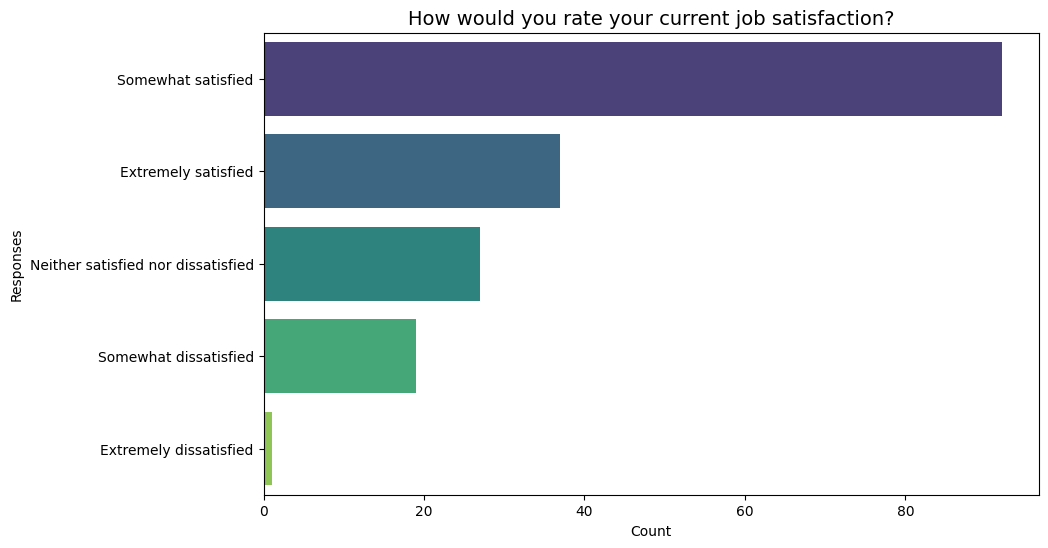

C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


Q21


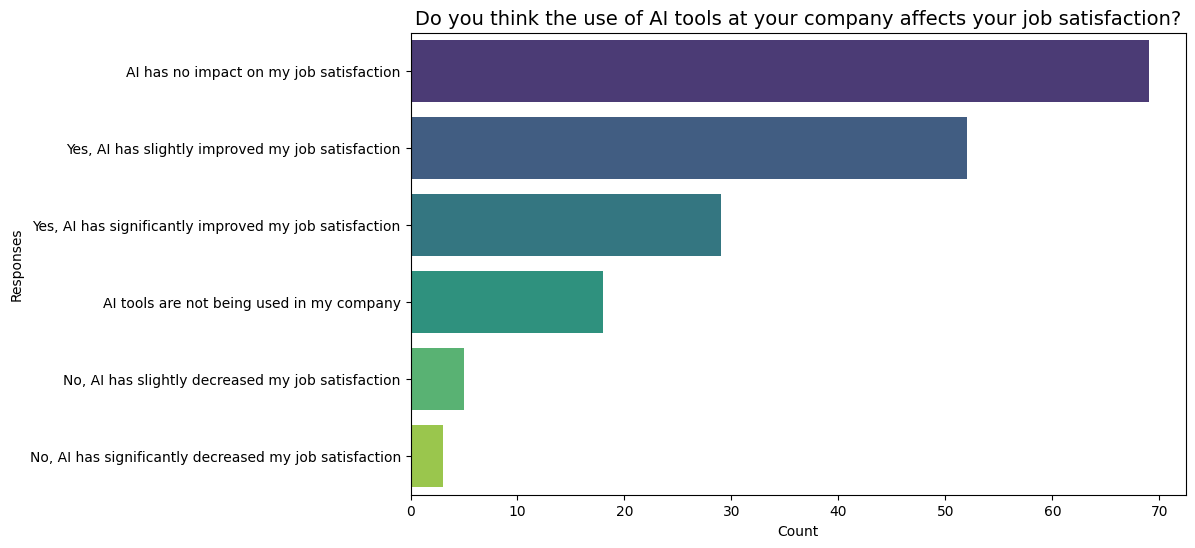

Q23


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


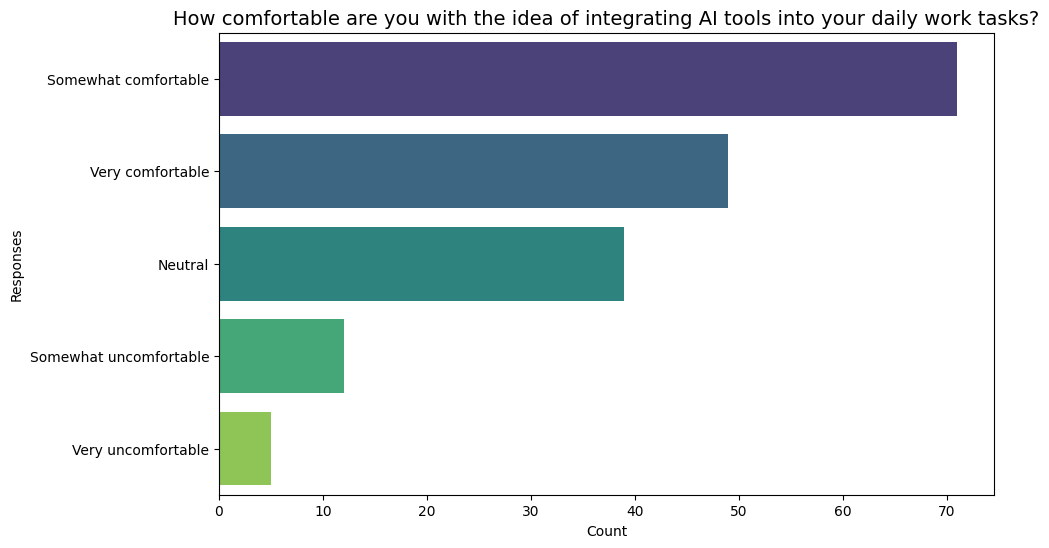

Q24


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


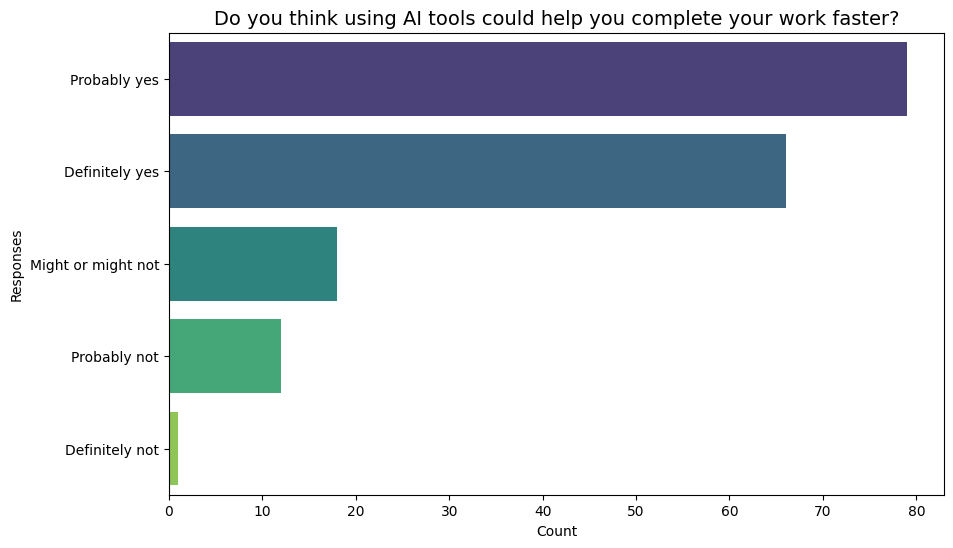

C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


Q25


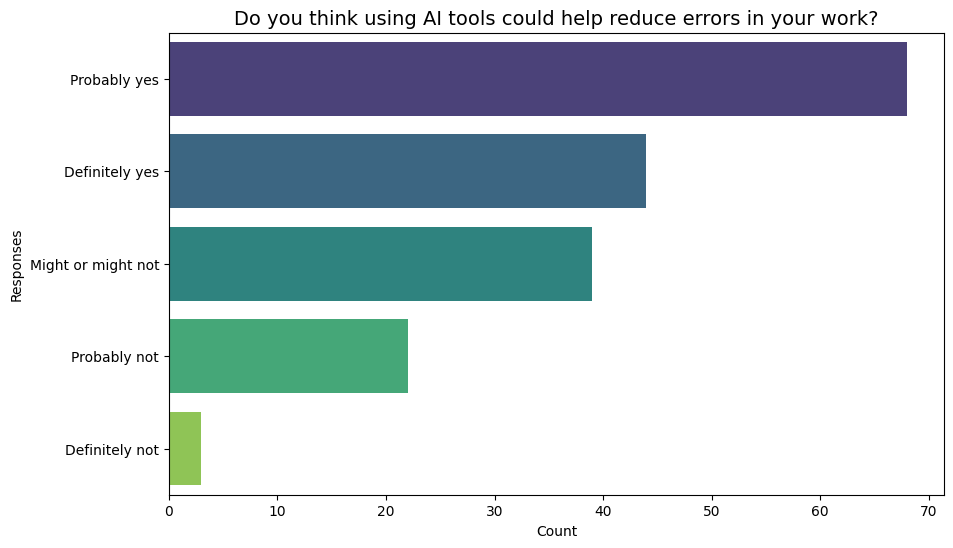

Q26


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


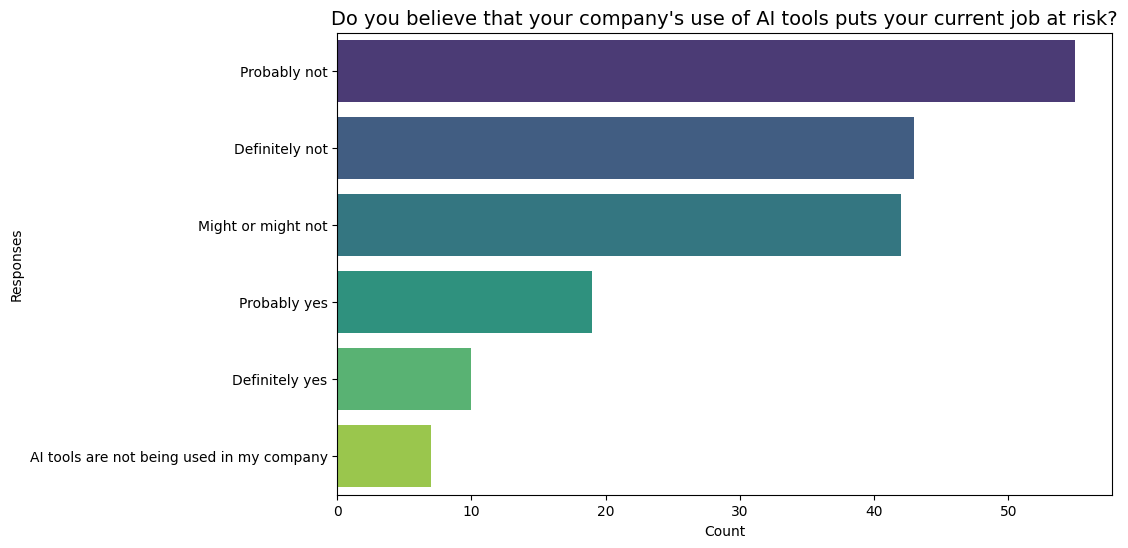

Q27


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


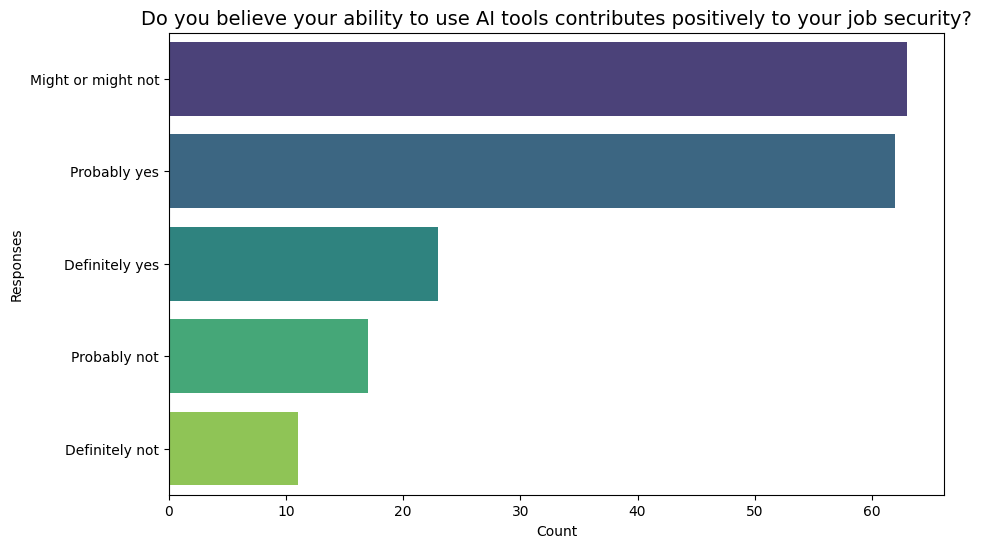

C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


Q28


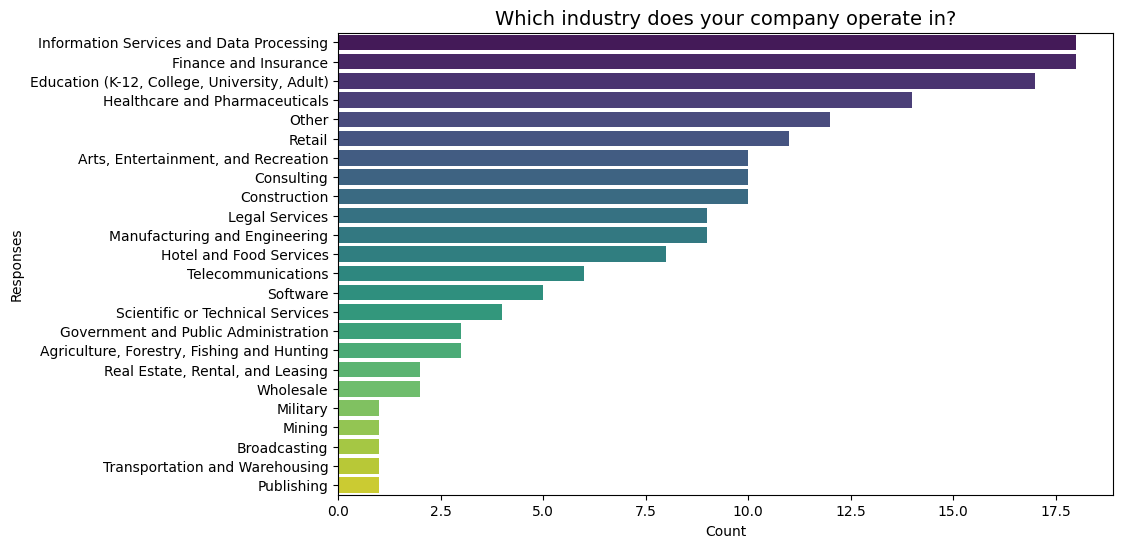

Q29


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


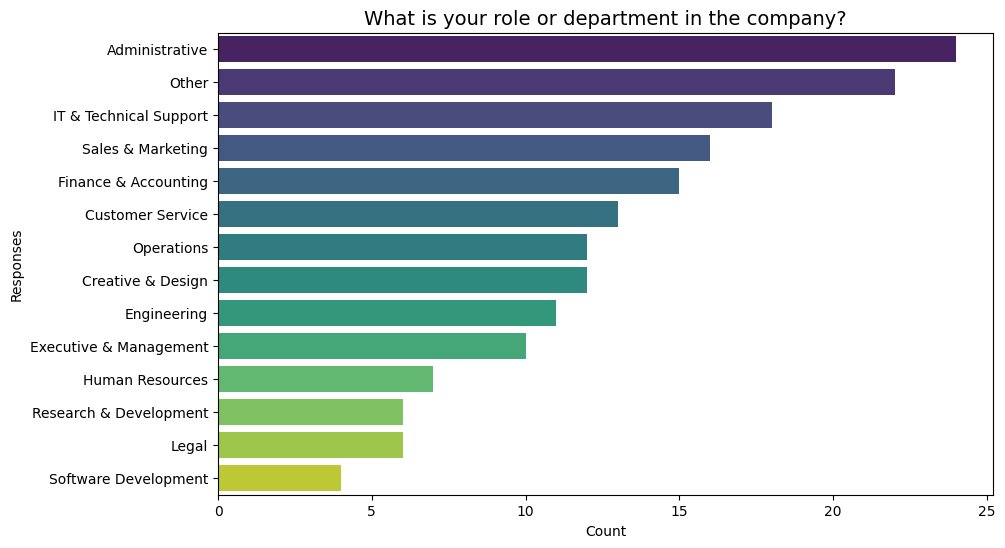

Q30


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


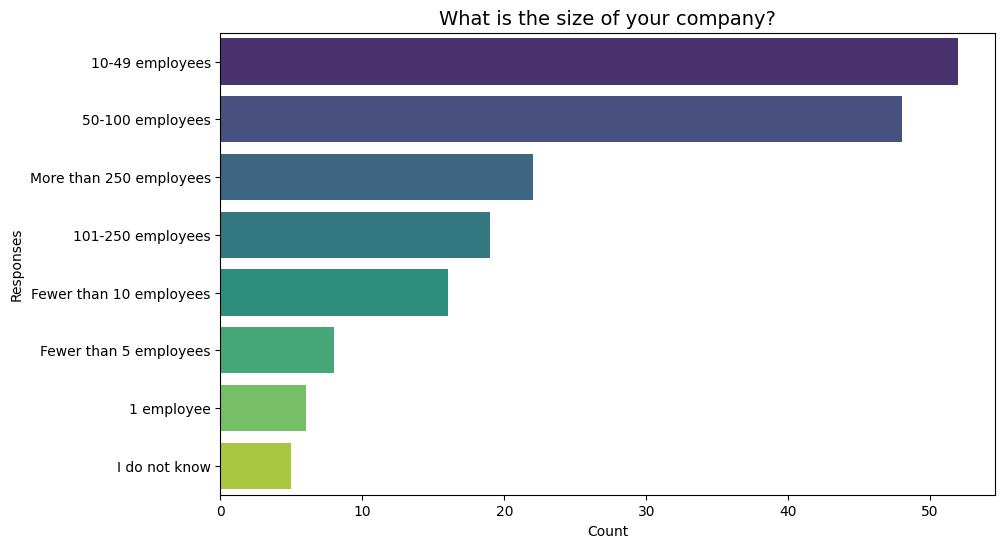

Q31


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


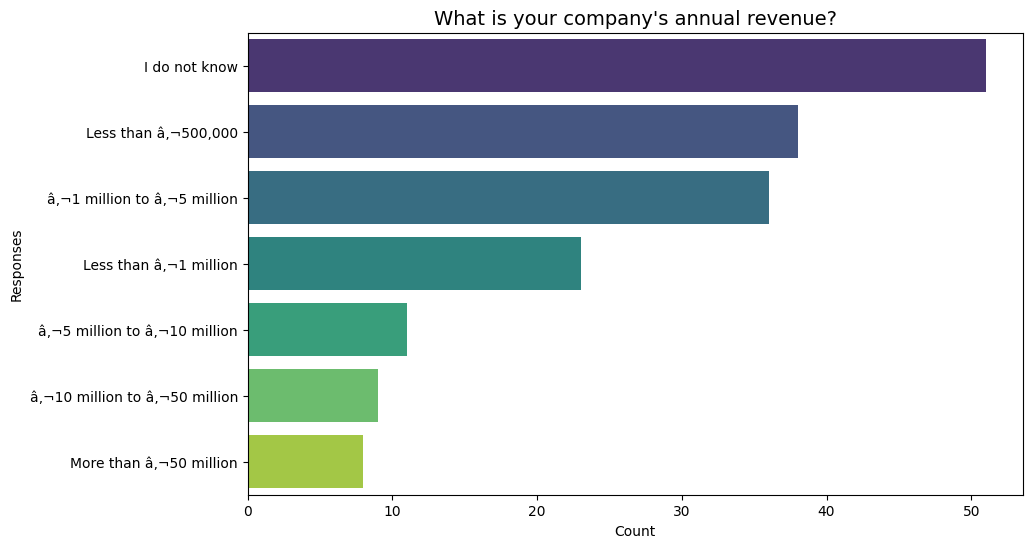

Q32


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


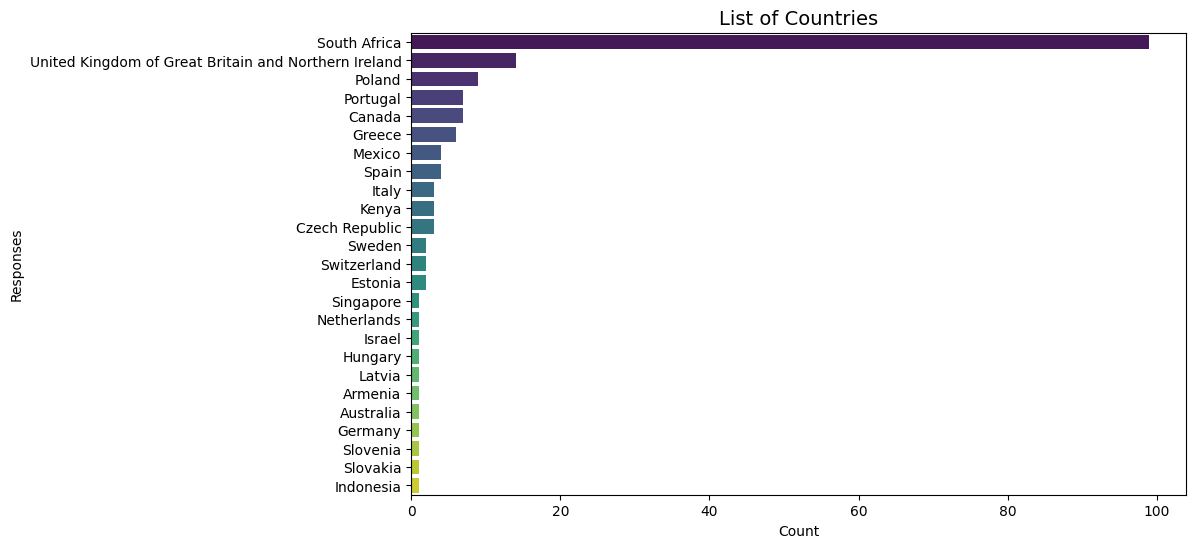

Q33


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


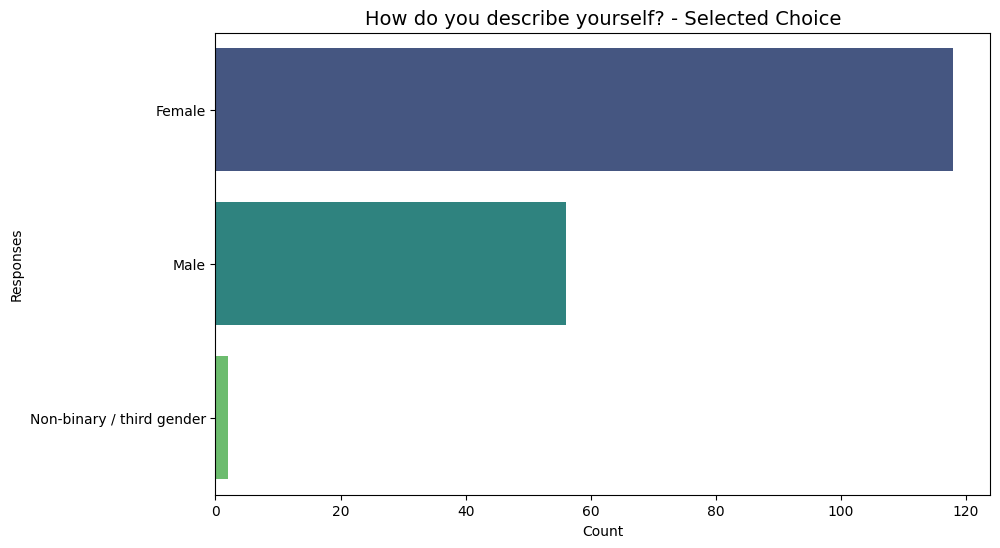

Q33_4_TEXT
No valid data for Q33_4_TEXT, skipping.
Q34


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


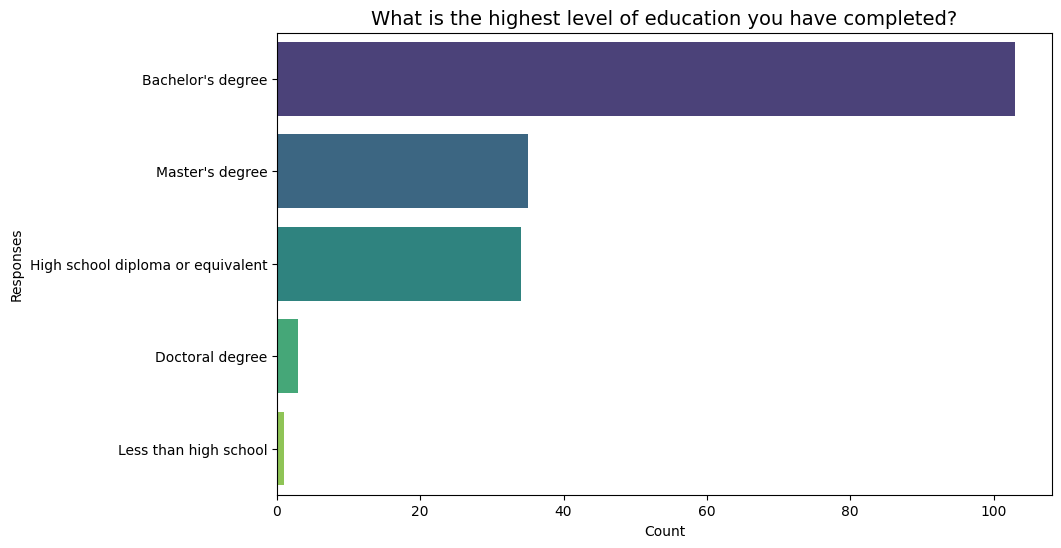

C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\2297711128.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')


Q35


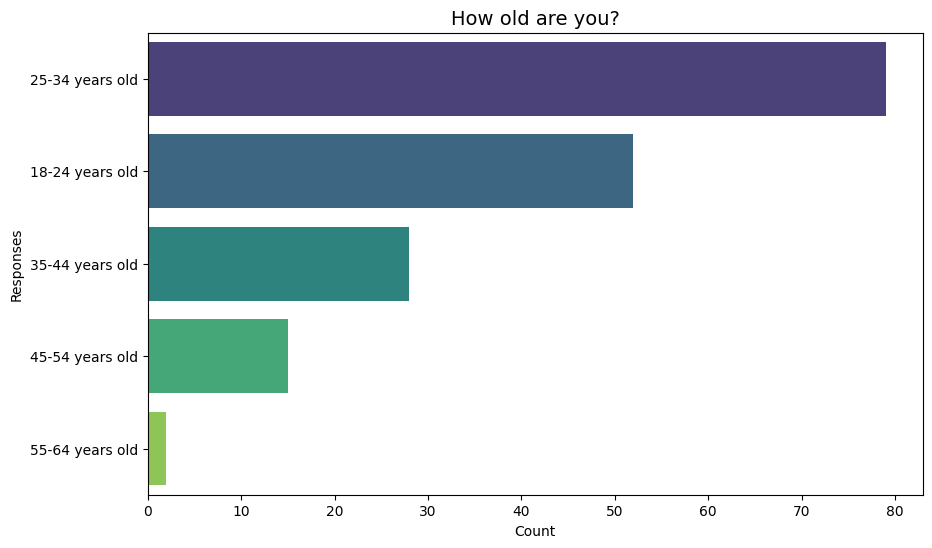

In [8]:
# Loop through the columns (questions) in 'data_questions'
for i in data_questions:
    # Extract the current question's column
    data_i = data[i]
    
    # Print the question column name (for debugging purposes or tracking)
    print(i)
    
    # Check if the column has valid data after skipping the first two rows
    if data_i[2:].dropna().empty:
        print(f"No valid data for {i}, skipping.")
        continue  # Skip to the next iteration if the data is empty
    
    # Create a figure with a specified size
    plt.figure(figsize=(10, 6))
    
    # Generate a count plot for the responses of the current question
    # Skipping the first two rows as they contain metadata, and plotting only the responses
    sns.countplot(y=data_i[2:], order=data_i[2:].dropna().value_counts().index, palette='viridis')
    
    # Set the title of the plot using the first row (question text)
    plt.title(data_i[0], fontsize=14)
    
    # Label the x-axis as 'Count' (number of responses)
    plt.xlabel('Count')
    
    # Label the y-axis as 'Responses' (response categories)
    plt.ylabel('Responses')
    
    # Display the plot
    plt.show()

In [9]:
data_Q10 = data['Q10']
data_Q10.unique()

array(['For what purposes are you using AI at work? - Selected Choice',
       '{"ImportId":"QID61"}', 'Automating repetitive tasks', 'Other',
       'Generating content (e.g., text, images, code),Customer support (e.g., chatbots)',
       'Automating repetitive tasks,Generating content (e.g., text, images, code),Enhancing productivity or workflow',
       'Decision-making assistance', 'None of the above',
       'Automating repetitive tasks,Generating content (e.g., text, images, code),Enhancing productivity or workflow,Personalization of products/services,Research and development,Decision-making assistance',
       'Generating content (e.g., text, images, code),Data analysis and insights,Research and development',
       'Automating repetitive tasks,Decision-making assistance',
       'Automating repetitive tasks,Generating content (e.g., text, images, code),Data analysis and insights,Research and development',
       'Generating content (e.g., text, images, code)',
       'Automatin

In [10]:
data_Q10_counts = data['Q10'].value_counts()

print(data_Q10_counts)

Q10
None of the above                                                                                                                                                                           30
Generating content (e.g., text, images, code)                                                                                                                                               12
Generating content (e.g., text, images, code),Research and development                                                                                                                       8
Research and development                                                                                                                                                                     5
Other                                                                                                                                                                                        4
                                         

In [51]:
# Initialize an empty dictionary to store counts
data_Q10_counts = {}

# Loop through each non-null entry in the 'Q10' column, skipping the first two rows (metadata)
for i in data['Q10'][2:].dropna():
    
    # Initialize an empty string to build words, and flags to track parentheses
    word = ''
    opened = False   # Tracks if an opening parenthesis is found
    closed = False   # Tracks if a closing parenthesis is found
    
    # Loop through each character in the string (response entry)
    for j in i:
        
        # If an opening parenthesis is found, set the flag to True (ignoring characters within parentheses)
        if j == '(':
            opened = True
            closed = False   # Reset the closed flag when a new parenthesis opens
        
        # If a closing parenthesis is found, set the flag to indicate it's closed
        if j == ')':
            opened = False   # Reset the opened flag
            closed = True    # Set the closed flag
        
        # If a comma is encountered, it indicates a separation between responses
        if j == ',':
            # If we have encountered a closed parenthesis, count the word and reset it
            if closed:
                if word not in data_Q10_counts:
                    data_Q10_counts[word] = 1   # If the word is new, initialize count to 1
                else:
                    data_Q10_counts[word] += 1  # If the word exists, increment its count
                word = ''  # Reset the word variable after processing
            
            # If parentheses are balanced (neither open nor closed), count the word
            elif opened == closed:
                if word not in data_Q10_counts:
                    data_Q10_counts[word] = 1   # Initialize count if word is new
                else:
                    data_Q10_counts[word] += 1  # Increment count if word exists
                word = ''  # Reset word variable
            else:
                word += j  # Continue building the word if inside parentheses
        
        else:
            # Continue building the word if it's not a comma or parenthesis
            word += j
    
    # After the loop, add the last word if it hasn't been counted
    if word not in data_Q10_counts:
        data_Q10_counts[word] = 1   # Initialize count for the last word
    else:
        data_Q10_counts[word] += 1  # Increment count for the last word

# Print the final dictionary with counts of each word
print(data_Q10_counts)

{'Automating repetitive tasks': 54, 'Other': 5, 'Generating content (e.g., text, images, code)': 86, 'Customer support (e.g., chatbots)': 47, 'Enhancing productivity or workflow': 53, 'Decision-making assistance': 43, 'None of the above': 30, 'Personalization of products/services': 25, 'Research and development': 78, 'Data analysis and insights': 48, 'Predictive analytics and forecasting': 16, 'Improving software or product development': 21}


C:\Users\Kira\AppData\Local\Temp\ipykernel_27440\1076508042.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Tool', x='Count', data=data10_df, palette='viridis')


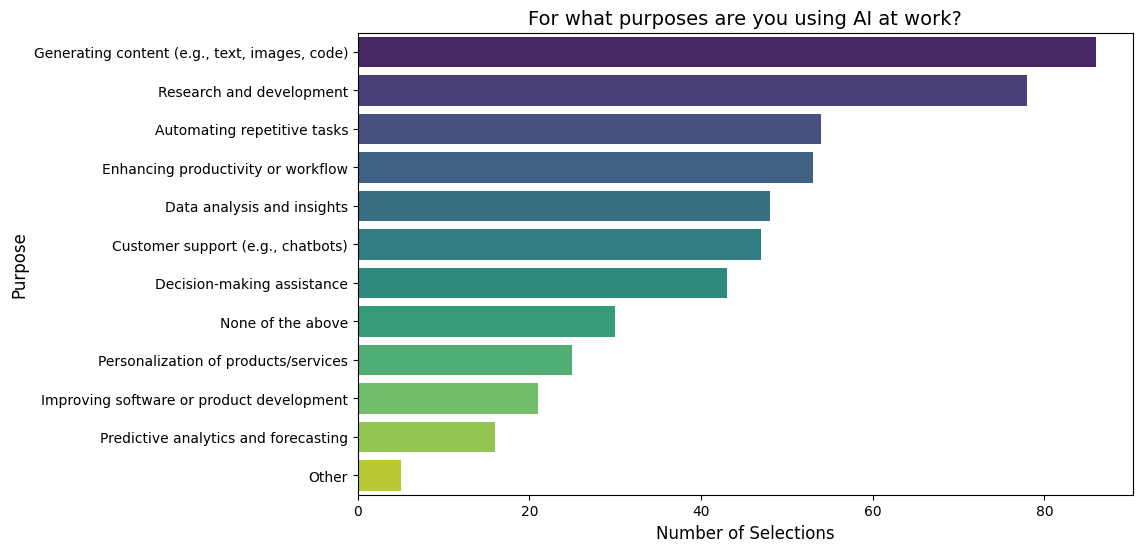

In [59]:
# Convert the dictionary to a DataFrame and sort by 'Count' in descending order
data10_df = pd.DataFrame(list(data_Q10_counts.items()), columns=['Tool', 'Count']).sort_values(by='Count', ascending=False)

# Plotting using seaborn's barplot with vertical bars
plt.figure(figsize=(10, 6))
sns.barplot(y='Tool', x='Count', data=data10_df, palette='viridis')

# Adding labels and title
plt.title('For what purposes are you using AI at work?', fontsize=14)
plt.xlabel('Number of Selections', fontsize=12)
plt.ylabel('Purpose', fontsize=12)

# Display the plot
plt.show()

In [10]:
# Check the age option
data_Q35 = data['Q35']
data_Q35.unique()

array(['How old are you?', '{"ImportId":"QID53"}', '25-34 years old',
       '55-64 years old', '35-44 years old', '18-24 years old',
       '45-54 years old', nan], dtype=object)

In [11]:
first_row = data.iloc[0]
print(first_row)

StartDate                                                       Start Date
EndDate                                                           End Date
Status                                                       Response Type
IPAddress                                                       IP Address
Progress                                                          Progress
Duration (in seconds)                                Duration (in seconds)
Finished                                                          Finished
RecordedDate                                                 Recorded Date
ResponseId                                                     Response ID
RecipientLastName                                      Recipient Last Name
RecipientFirstName                                    Recipient First Name
RecipientEmail                                             Recipient Email
ExternalReference                                  External Data Reference
LocationLatitude         

In [66]:
# Create a mapping for age groups with numerical values
age_mapping = {
    '18-24 years old': 1,
    '25-34 years old': 2,
    '35-44 years old': 3,
    '45-54 years old': 4,
    '55-64 years old': 5,
    '65+ years old': 6
}

# Map the age responses (Q35) to the corresponding numerical values
data['age_encoded'] = data['Q35'].map(age_mapping)

# Create a mapping for willingness levels with numerical values
willingness_mapping = {
    'Not interested at all': 1,
    'Not very interested': 2,
    'Somewhat interested': 3,
    'Neutral': 4,
    'Very interested': 5
}

# Map the willingness responses (Q12) to the corresponding numerical values
data['willingness_encoded'] = data['Q12'].map(willingness_mapping)

In [67]:
# Perform a one-way ANOVA test to check if there's a significant difference in willingness
# across different age groups. Each group is filtered by 'age_encoded' and non-null values 
# of 'willingness_encoded' are selected for analysis.

anova_results = stats.f_oneway(
    data[data['age_encoded'] == 1]['willingness_encoded'].dropna(),  # Group 1: Age 18-24
    data[data['age_encoded'] == 2]['willingness_encoded'].dropna(),  # Group 2: Age 25-34
    data[data['age_encoded'] == 3]['willingness_encoded'].dropna(),  # Group 3: Age 35-44
    data[data['age_encoded'] == 4]['willingness_encoded'].dropna(),  # Group 4: Age 45-54
    data[data['age_encoded'] == 5]['willingness_encoded'].dropna()   # Group 5: Age 55-64
)

# Print the ANOVA results: F-statistic and p-value
print(f'ANOVA F-statistic: {anova_results.statistic}, p-value: {anova_results.pvalue}')

ANOVA F-statistic: 0.5835395232191753, p-value: 0.6749721068194483


In [68]:
# Extract age groups and willingness responses from the data
age_groups = data['Q35']  # Column representing age groups
willingness = data['Q12']  # Column representing willingness responses

# Create a summary DataFrame with age groups and willingness
summary = pd.DataFrame({
    'Age Group': age_groups,
    'Willingness': willingness
})

# Drop rows with missing values to ensure clean data
summary.dropna(inplace=True)

# Group by Age Group and Willingness, counting occurrences and unstacking for better readability
count_summary = summary.groupby(['Age Group', 'Willingness']).size().unstack(fill_value=0)

# Print the summary of counts for each combination of age group and willingness
print(count_summary)

# Initialize a list to hold the final summary data
final_summary_data = []

# Loop through each age group in the count summary
for age_group in count_summary.index:
    response_counts = count_summary.loc[age_group]  # Get the response counts for the current age group
    # Create a string representation of the response counts
    response_list = ', '.join(f"{count} ({response})" for response, count in response_counts.items() if count > 0)
    # Append a dictionary with the age group and corresponding responses to the final summary data
    final_summary_data.append({'Age Group': age_group, 'Responses': response_list})

# Create a final summary DataFrame from the summary data
final_summary_df = pd.DataFrame(final_summary_data)
final_summary_df  # Display the final summary DataFrame

Willingness           How interested are you in learning to use generative AI tools (e.g., ChatGPT, DALLÂ·E) to enhance your work in your current role?  \
Age Group                                                                                                                                                 
18-24 years old                                                       0                                                                                   
25-34 years old                                                       0                                                                                   
35-44 years old                                                       0                                                                                   
45-54 years old                                                       0                                                                                   
55-64 years old                                                       

,Age Group,Responses
0,18-24 years old,"2 (Neutral), 1 (Not very interested), 15 (Some..."
1,25-34 years old,"3 (Neutral), 6 (Not very interested), 21 (Some..."
2,35-44 years old,"2 (Neutral), 1 (Not very interested), 9 (Somew..."
3,45-54 years old,"1 (Neutral), 1 (Not interested at all), 6 (Som..."
4,55-64 years old,"1 (Somewhat interested), 1 (Very interested)"
5,How old are you?,1 (How interested are you in learning to use g...
6,"{""ImportId"":""QID53""}","1 ({""ImportId"":""QID63""})"


In [15]:
final_summary_df.to_csv('Willingness.csv', index=False)

In [69]:
data['StartDate'].count()

179

In [70]:
data['Q13']

0      How much time are you willing to spend on lear...
1                                   {"ImportId":"QID12"}
2                                              1-3 hours
3                                              1-3 hours
4                                              3-5 hours
                             ...                        
174                                            1-3 hours
175                                            1-3 hours
176                                            1-3 hours
177                                            1-3 hours
178                                            1-3 hours
Name: Q13, Length: 179, dtype: object

In [71]:
data['Q13'].unique()

array(['How much time are you willing to spend on learning new generative AI tools per week?',
       '{"ImportId":"QID12"}', '1-3 hours', '3-5 hours',
       'Less than 1 hour', 'More than 10 hours', '5-10 hours',
       'I would prefer one-time learning dedication (not weekly recurring)',
       nan], dtype=object)

In [19]:
# Define a mapping for learning time preferences to numerical values
learning_time_mapping = {
    "I would prefer one-time learning dedication (not weekly recurring)": 1,  # One-time learning preference
    'Less than 1 hour': 2,  # Less than 1 hour
    '1-3 hours': 3,         # 1-3 hours
    '3-5 hours': 4,         # 3-5 hours
    '5-10 hours': 5,        # 5-10 hours
    'More than 10 hours': 6  # More than 10 hours
}

# Encode the learning time preferences in the dataset using the defined mapping
data['learning_time_encoded'] = data['Q13'].map(learning_time_mapping)  # Map preferences to numerical values

In [72]:
# Extracting age groups and learning time responses from the dataset
age_groups = data['Q35']  # Age group responses
learning_time = data['Q13']  # Learning time responses

# Creating a summary DataFrame with age groups and learning time
summary = pd.DataFrame({
    'Age Group': age_groups,
    'Learning time': learning_time
})

# Dropping any rows with missing values
summary.dropna(inplace=True)

# Grouping by age group and learning time, then counting occurrences
count_summary = summary.groupby(['Age Group', 'Learning time']).size().unstack(fill_value=0)

# Print the summary of counts
print(count_summary)

# Preparing final summary data for output
final_summary_data = []

# Iterating through each age group in the count summary
for age_group in count_summary.index:
    response_counts = count_summary.loc[age_group]  # Get response counts for the current age group
    # Creating a formatted string of counts and corresponding responses
    response_list = ', '.join(f"{count} ({response})" for response, count in response_counts.items() if count > 0)
    final_summary_data.append({'Age Group': age_group, 'Responses': response_list})  # Append to final data

# Converting the final summary data to a DataFrame
final_summary_df = pd.DataFrame(final_summary_data)

# Display the final summary DataFrame
final_summary_df

Learning time         1-3 hours  3-5 hours  5-10 hours  \
Age Group                                                
18-24 years old              30         10           3   
25-34 years old              31         17           9   
35-44 years old              12          8           1   
45-54 years old               6          3           0   
55-64 years old               2          0           0   
How old are you?              0          0           0   
{"ImportId":"QID53"}          0          0           0   

Learning time         How much time are you willing to spend on learning new generative AI tools per week?  \
Age Group                                                                                                    
18-24 years old                                                       0                                      
25-34 years old                                                       0                                      
35-44 years old                      

,Age Group,Responses
0,18-24 years old,"30 (1-3 hours), 10 (3-5 hours), 3 (5-10 hours)..."
1,25-34 years old,"31 (1-3 hours), 17 (3-5 hours), 9 (5-10 hours)..."
2,35-44 years old,"12 (1-3 hours), 8 (3-5 hours), 1 (5-10 hours),..."
3,45-54 years old,"6 (1-3 hours), 3 (3-5 hours), 3 (I would prefe..."
4,55-64 years old,2 (1-3 hours)
5,How old are you?,1 (How much time are you willing to spend on l...
6,"{""ImportId"":""QID53""}","1 ({""ImportId"":""QID12""})"


In [21]:
final_summary_df.to_csv('Learning time.csv', index=False)

In [73]:
summary=summary.drop(index=1)

In [74]:
summary=summary.drop(index=0)

In [75]:
summary[summary['Learning time']=='1-3 hours'].count()

Age Group        81
Learning time    81
dtype: int64

In [76]:
summary

,Age Group,Learning time
2,25-34 years old,1-3 hours
3,55-64 years old,1-3 hours
4,25-34 years old,3-5 hours
5,35-44 years old,Less than 1 hour
6,25-34 years old,Less than 1 hour
...,...,...
174,35-44 years old,1-3 hours
175,25-34 years old,1-3 hours
176,25-34 years old,1-3 hours
177,18-24 years old,1-3 hours


C:\Users\Kira\AppData\Local\Temp\ipykernel_79852\20471314.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Age Group', data=summary, order=summary['Age Group'].value_counts().index, palette='viridis')


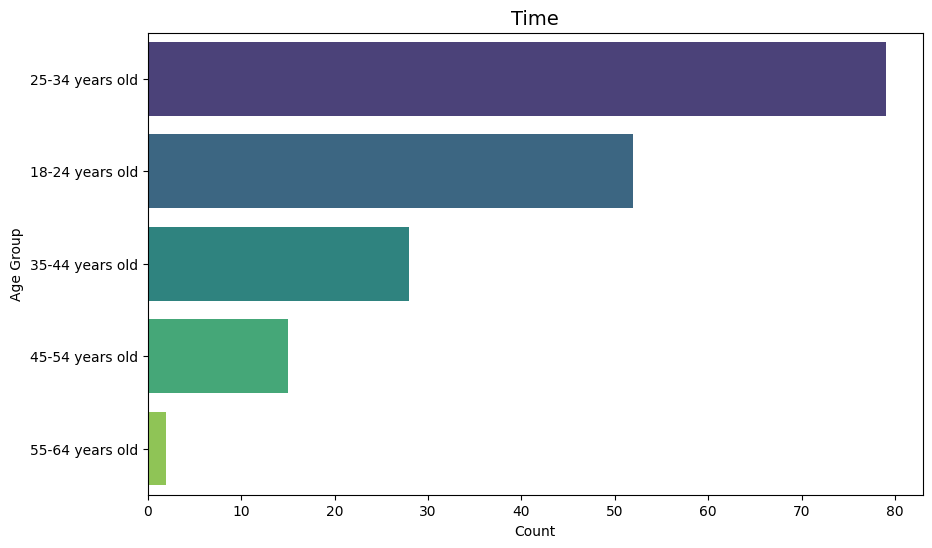

In [26]:
plt.figure(figsize=(10, 6))
# Using countplot to plot the counts of 'Age Group'
sns.countplot(y='Age Group', data=summary, order=summary['Age Group'].value_counts().index, palette='viridis')

plt.title("Time", fontsize=14)
plt.xlabel('Count')
plt.ylabel('Age Group')
plt.show()

### Calculate willingness score using X * Y

In [28]:
data['Willingness Score'] = data['willingness_encoded'] * data['learning_time_encoded']

In [29]:
data = data.drop(index=0)
data = data.drop(index=1)
data

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,Q32,Q33,Q33_4_TEXT,Q34,Q35,PROLIFIC_PID,age_encoded,willingness_encoded,learning_time_encoded,Willingness Score
2,2024-09-30 15:25:55,2024-09-30 15:26:57,Survey Preview,NaN,100,61,true,2024-09-30 15:26:57,R_8ROpmDdiy6hYKAd,NaN,...,Armenia,Male,NaN,Less than high school,25-34 years old,NaN,2.0,4.0,3.0,12.0
3,2024-09-30 15:34:16,2024-09-30 15:36:38,IP Address,5.146.132.253,100,141,true,2024-09-30 15:36:39,R_2lnmn9ItoIScqBw,NaN,...,Germany,Male,NaN,High school diploma or equivalent,55-64 years old,6605c195e4727703228ef777,5.0,5.0,3.0,15.0
4,2024-09-30 15:33:56,2024-09-30 15:36:42,IP Address,213.81.156.126,100,166,true,2024-09-30 15:36:42,R_8hAWYwXpiTglZvR,NaN,...,Slovakia,Female,NaN,Bachelor's degree,25-34 years old,663ad1e9c4066faf455c913d,2.0,3.0,4.0,12.0
5,2024-09-30 15:34:40,2024-09-30 15:37:00,IP Address,130.25.152.228,100,140,true,2024-09-30 15:37:01,R_8eJ9iFhhZqdyNHz,NaN,...,Italy,Female,NaN,Bachelor's degree,35-44 years old,664c8166a7f70060beb205b3,3.0,5.0,2.0,10.0
6,2024-09-30 15:35:09,2024-09-30 15:38:12,IP Address,94.8.202.72,100,183,true,2024-09-30 15:38:13,R_25McYZWcxSJZ24F,NaN,...,United Kingdom of Great Britain and Northern I...,Female,NaN,Master's degree,25-34 years old,5ca73fcf7067e70001f7a41f,2.0,3.0,2.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,2024-09-30 15:39:52,2024-09-30 16:00:43,IP Address,85.74.105.33,100,1250,true,2024-09-30 16:00:44,R_2iez02Xrvftsxbj,NaN,...,Greece,Female,NaN,Master's degree,35-44 years old,615d8873c11a1982c8838b54,3.0,5.0,3.0,15.0
175,2024-09-30 15:38:36,2024-09-30 16:02:40,IP Address,41.147.3.40,100,1444,true,2024-09-30 16:02:42,R_2fJ4S7zrX2uJfHS,NaN,...,South Africa,Female,NaN,Bachelor's degree,25-34 years old,5fd391f111059f000ac10cde,2.0,5.0,3.0,15.0
176,2024-09-30 15:43:32,2024-09-30 16:11:45,IP Address,79.107.61.6,100,1692,true,2024-09-30 16:11:45,R_8YHxPcFtHbenqJX,NaN,...,Greece,Male,NaN,High school diploma or equivalent,25-34 years old,5ede000fb1248f0009695ab4,2.0,5.0,3.0,15.0
177,2024-09-30 15:39:47,2024-09-30 16:12:38,IP Address,105.184.169.187,100,1971,true,2024-09-30 16:12:39,R_2oZyjQacDsq3g3n,NaN,...,South Africa,Male,NaN,Bachelor's degree,18-24 years old,64835cdc41f91285bcbd2de1,1.0,5.0,3.0,15.0


C:\Users\Kira\AppData\Local\Temp\ipykernel_79852\866414507.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Q35', y='Willingness Score', data=data, palette='viridis')


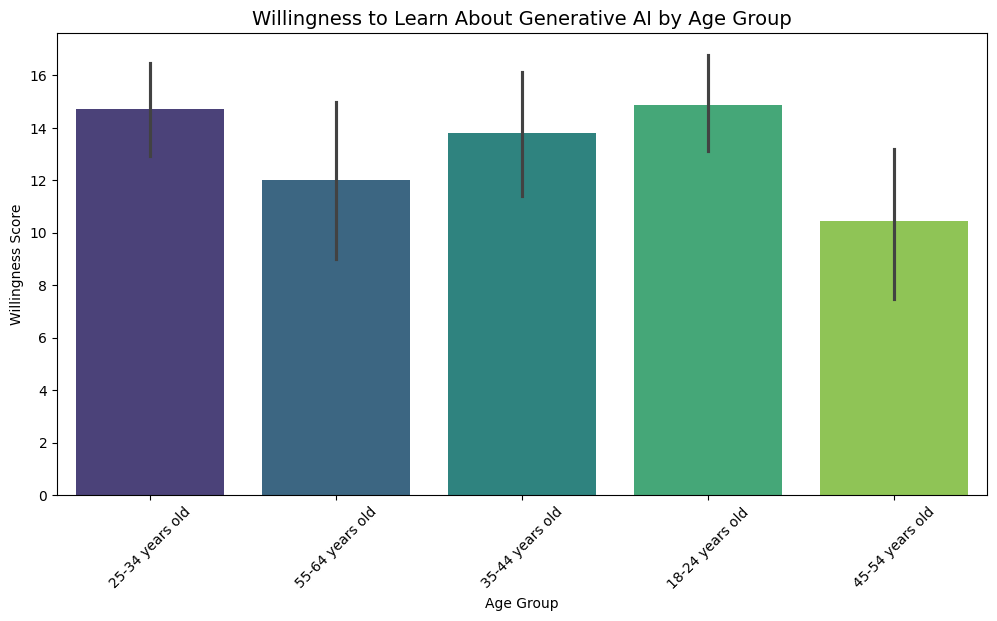

In [30]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Q35', y='Willingness Score', data=data, palette='viridis')
plt.title("Willingness to Learn About Generative AI by Age Group", fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Willingness Score')
plt.xticks(rotation=45)
plt.show()

C:\Users\Kira\AppData\Local\Temp\ipykernel_79852\1275889070.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Q35',y='Willingness Score', data=data, palette='viridis')


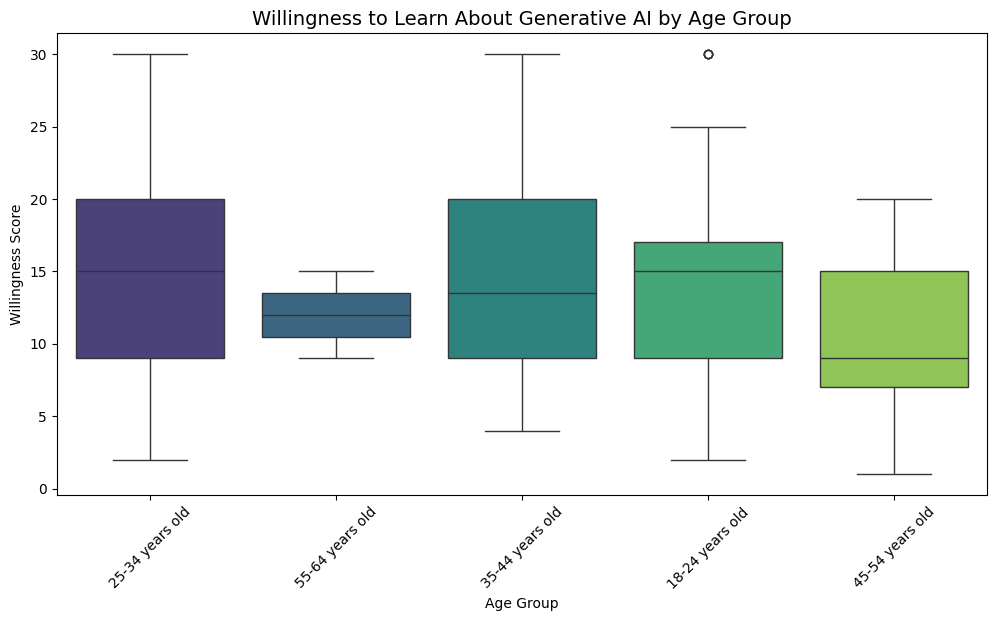

In [31]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Q35',y='Willingness Score', data=data, palette='viridis')
plt.title("Willingness to Learn About Generative AI by Age Group", fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Willingness Score')
plt.xticks(rotation=45)
plt.show()

In [32]:
data['Q35'].value_counts()

Q35
25-34 years old    79
18-24 years old    52
35-44 years old    28
45-54 years old    15
55-64 years old     2
Name: count, dtype: int64

In [33]:
anova_results = stats.f_oneway(
    data[data['age_encoded'] == 1]['Willingness Score'].dropna(),
    data[data['age_encoded'] == 2]['Willingness Score'].dropna(),
    data[data['age_encoded'] == 3]['Willingness Score'].dropna(),
    data[data['age_encoded'] == 4]['Willingness Score'].dropna()
)

print(f'ANOVA F-statistic: {anova_results.statistic}, p-value: {anova_results.pvalue}')

ANOVA F-statistic: 1.8061659748146888, p-value: 0.1479195760060749


In [78]:
# Initialize an empty list to store unique values from question Q16
uniqueValuesQ16 = []

# Iterate through each entry in the 'Q16' column of the data
for i in list(data['Q16'][2:]):
    try:
        # Split the entry by commas and iterate through the resulting values
        for j in i.split(','):
            # If the value is not already in the unique list, add it
            if j not in uniqueValuesQ16:
                uniqueValuesQ16.append(j)
    except:
        # Continue to the next entry if there's an error (e.g., if the entry is NaN)
        continue

# Print each unique value found in Q16
for i in uniqueValuesQ16:
    print(i)

Lack of time
Lack of access to resources or training
Lack of support from management or organization
Concern that AI may not be relevant to my role
Fear of AI replacing jobs
Difficulty understanding the concepts
Uncertainty about where to start
No significant barriers
Other


In [35]:
# Let's define the inputs for the different cases and calculate the scores based on the formula:
# Score = Interest * (Time - Barriers)

# We will define the following scales:
# Interest: 'Not at all' = 0, 'Not very interested' = 0.25, 'Neutral' = 0.5, 'Somewhat interested' = 0.75, 'Very interested' = 1
# Time: 'One time workshop' = 0.1, '1-3h per week' = 0.25, '3-5h per week' = 0.5, '5-10h per week' = 0.75, '+10h per week' = 1
# Barriers: 'No significant barriers' = 0, 'Lack of time or resources' = 0.5, 'Multiple barriers' = 0.75

# The combinations for each case will be computed.

import pandas as pd

# Defining the values for Interest, Time, and Barriers
interest_levels = {
    'Not at all': 0,
    'Not very interested': 0.25,
    'Neutral': 0.5,
    'Somewhat interested': 0.75,
    'Very interested': 1
}

time_levels = {
    'One time workshop': 0.1,
    '1-3h per week': 0.25,
    '3-5h per week': 0.5,
    '5-10h per week': 0.75,
    '+10h per week': 1
}

barriers_levels = {
    'No significant barriers': 0,
    'Lack of time or resources': 0.5,
    'Multiple barriers': 0.75
}

# Creating a DataFrame to calculate the scores for all combinations
scores = []
for interest, interest_value in interest_levels.items():
    for time, time_value in time_levels.items():
        for barriers, barriers_value in barriers_levels.items():
            score = interest_value * (time_value - barriers_value)
            scores.append([interest, time, barriers, score])

# Convert the result into a DataFrame for better readability
df_scores = pd.DataFrame(scores, columns=['Interest', 'Time', 'Barriers', 'Score'])
df_scores.sort_values(by=['Interest', 'Time', 'Barriers'], inplace=True)

df_scores

,Interest,Time,Barriers,Score
43,Neutral,+10h per week,Lack of time or resources,0.250
44,Neutral,+10h per week,Multiple barriers,0.125
42,Neutral,+10h per week,No significant barriers,0.500
34,Neutral,1-3h per week,Lack of time or resources,-0.125
35,Neutral,1-3h per week,Multiple barriers,-0.250
...,...,...,...,...
71,Very interested,5-10h per week,Multiple barriers,0.000
69,Very interested,5-10h per week,No significant barriers,0.750
61,Very interested,One time workshop,Lack of time or resources,-0.400
62,Very interested,One time workshop,Multiple barriers,-0.650


In [36]:
pd.set_option('display.max_rows', None)

In [37]:
df_scores

,Interest,Time,Barriers,Score
43,Neutral,+10h per week,Lack of time or resources,0.2500
44,Neutral,+10h per week,Multiple barriers,0.1250
42,Neutral,+10h per week,No significant barriers,0.5000
34,Neutral,1-3h per week,Lack of time or resources,-0.1250
35,Neutral,1-3h per week,Multiple barriers,-0.2500
33,Neutral,1-3h per week,No significant barriers,0.1250
37,Neutral,3-5h per week,Lack of time or resources,0.0000
38,Neutral,3-5h per week,Multiple barriers,-0.1250
36,Neutral,3-5h per week,No significant barriers,0.2500
40,Neutral,5-10h per week,Lack of time or resources,0.1250


In [38]:
# Adjust the formula: if the barrier is 'Lack of time or resources', then increase the time score instead of decreasing it.
# This will allow us to reflect the willingness to learn despite the constraint.

# Adjusted score calculation:
# If barrier is 'Lack of time or resources', we add 0.2 to the time value to account for their willingness despite the constraint.

def calculate_score(interest_value, time_value, barriers_value, barriers_type):
    # Adjust time if the barrier is 'Lack of time or resources'
    if barriers_type == 'Lack of time or resources':
        time_value += 0.2  # Boost the time score if this barrier is selected
    score = interest_value * (time_value - barriers_value)
    return score

# Recalculate the scores with the updated formula
scores_adjusted = []
for interest, interest_value in interest_levels.items():
    for time, time_value in time_levels.items():
        for barriers, barriers_value in barriers_levels.items():
            adjusted_score = calculate_score(interest_value, time_value, barriers_value, barriers)
            scores_adjusted.append([interest, time, barriers, adjusted_score])

# Convert the result into a DataFrame
df_scores_adjusted = pd.DataFrame(scores_adjusted, columns=['Interest', 'Time', 'Barriers', 'Score'])
df_scores_adjusted.sort_values(by=['Interest', 'Time', 'Barriers'], inplace=True)

df_scores_adjusted

,Interest,Time,Barriers,Score
43,Neutral,+10h per week,Lack of time or resources,0.3500
44,Neutral,+10h per week,Multiple barriers,0.1250
42,Neutral,+10h per week,No significant barriers,0.5000
34,Neutral,1-3h per week,Lack of time or resources,-0.0250
35,Neutral,1-3h per week,Multiple barriers,-0.2500
33,Neutral,1-3h per week,No significant barriers,0.1250
37,Neutral,3-5h per week,Lack of time or resources,0.1000
38,Neutral,3-5h per week,Multiple barriers,-0.1250
36,Neutral,3-5h per week,No significant barriers,0.2500
40,Neutral,5-10h per week,Lack of time or resources,0.2250


In [39]:
def calculate_score_adjusted(interest_value, time_value, barriers_value, barriers_type):
    # If the person faces "multiple barriers" but still allocates more time, reduce the negative impact of the barriers.
    if barriers_type == 'Multiple barriers' and time_value >= 0.5:  # '3-5h per week' or more
        barriers_value = barriers_value / 2  # Reduce the negative impact of barriers
    elif barriers_type == 'Lack of time or resources':
        time_value += 0.2  # Boost the time score if this barrier is selected

    # Calculate the final score
    score = interest_value * (time_value - barriers_value)
    return score

# Recalculate the scores with the further refined formula
scores_refined = []
for interest, interest_value in interest_levels.items():
    for time, time_value in time_levels.items():
        for barriers, barriers_value in barriers_levels.items():
            refined_score = calculate_score_adjusted(interest_value, time_value, barriers_value, barriers)
            scores_refined.append([interest, time, barriers, refined_score])

# Convert the result into a DataFrame
df_scores_refined = pd.DataFrame(scores_refined, columns=['Interest', 'Time', 'Barriers', 'Score'])
df_scores_refined.sort_values(by=['Interest', 'Time', 'Barriers'], inplace=True)

df_scores_refined

,Interest,Time,Barriers,Score
43,Neutral,+10h per week,Lack of time or resources,0.35000
44,Neutral,+10h per week,Multiple barriers,0.31250
42,Neutral,+10h per week,No significant barriers,0.50000
34,Neutral,1-3h per week,Lack of time or resources,-0.02500
35,Neutral,1-3h per week,Multiple barriers,-0.25000
33,Neutral,1-3h per week,No significant barriers,0.12500
37,Neutral,3-5h per week,Lack of time or resources,0.10000
38,Neutral,3-5h per week,Multiple barriers,0.06250
36,Neutral,3-5h per week,No significant barriers,0.25000
40,Neutral,5-10h per week,Lack of time or resources,0.22500


In [40]:
def calculate_score_boosted(interest_value, time_value, barriers_value, barriers_type):
    # If there are barriers and a significant time is chosen (e.g., 5-10h or more), boost the score more
    if barriers_type in ['Lack of time or resources', 'Multiple barriers'] and time_value >= 0.8:  # '5-10h per week' or more
        time_value += 0.2  # Boost the time value more to reflect willingness despite barriers
    elif barriers_type == 'Lack of time or resources':
        time_value += 0.2  # Smaller boost for less significant time commitments if lack of time is chosen
    
    # Calculate the final score
    score = interest_value * (time_value - barriers_value)
    return score

# Recalculate the scores with the new logic
scores_boosted = []
for interest, interest_value in interest_levels.items():
    for time, time_value in time_levels.items():
        for barriers, barriers_value in barriers_levels.items():
            boosted_score = calculate_score_boosted(interest_value, time_value, barriers_value, barriers)
            scores_boosted.append([interest, time, barriers, boosted_score])

# Convert the result into a DataFrame
df_scores_boosted = pd.DataFrame(scores_boosted, columns=['Interest', 'Time', 'Barriers', 'Score'])
df_scores_boosted.sort_values(by=['Interest', 'Time', 'Barriers'], inplace=True)

df_scores_boosted


,Interest,Time,Barriers,Score
43,Neutral,+10h per week,Lack of time or resources,0.3500
44,Neutral,+10h per week,Multiple barriers,0.2250
42,Neutral,+10h per week,No significant barriers,0.5000
34,Neutral,1-3h per week,Lack of time or resources,-0.0250
35,Neutral,1-3h per week,Multiple barriers,-0.2500
33,Neutral,1-3h per week,No significant barriers,0.1250
37,Neutral,3-5h per week,Lack of time or resources,0.1000
38,Neutral,3-5h per week,Multiple barriers,-0.1250
36,Neutral,3-5h per week,No significant barriers,0.2500
40,Neutral,5-10h per week,Lack of time or resources,0.2250


In [41]:
# Calculate willingness score
class Learner:
    def __init__(self, interest, time_available, barriers):
        self.interest = interest  # Interest level (0 to 5)
        self.time_available = time_available  # Time available (0 to 6)
        self.barriers = barriers  # Barriers (0 to 6, can be derived from learning time)

    def calculate_score(self):
        # Weights for the calculation (can be adjusted as needed)
        weight_interest = 1.5
        weight_time = 1.0
        weight_barriers = 1.2
        numerator = (self.interest * weight_interest) + \
                    (self.time_available * weight_time) - \
                    (self.barriers * weight_barriers)
        denominator = weight_interest + weight_time + weight_barriers
        score = numerator / denominator
        return score

# Calculate scores and summarize
data['score'] = data.apply(lambda row: Learner(row['willingness_encoded'], row['learning_time_encoded'], 0).calculate_score(), axis=1)

# Summarizing scores by age group
summary = data.groupby('Q35')['score'].agg(['count', 'mean']).reset_index()
summary.columns = ['Age Group', 'Count', 'Average Score']

# Display the summary
print(summary)

         Age Group  Count  Average Score
0  18-24 years old     52       2.668919
1  25-34 years old     79       2.620595
2  35-44 years old     28       2.562741
3  45-54 years old     15       2.270270
4  55-64 years old      2       2.432432


In [45]:
summary, data[['Q35', 'Q12', 'Q13', 'score']]

(         Age Group  Count  Average Score
 0  18-24 years old     52       2.668919
 1  25-34 years old     79       2.620595
 2  35-44 years old     28       2.562741
 3  45-54 years old     15       2.270270
 4  55-64 years old      2       2.432432,
                  Q35                    Q12  \
 2    25-34 years old                Neutral   
 3    55-64 years old        Very interested   
 4    25-34 years old    Somewhat interested   
 5    35-44 years old        Very interested   
 6    25-34 years old    Somewhat interested   
 7    25-34 years old        Very interested   
 8    18-24 years old        Very interested   
 9    35-44 years old        Very interested   
 10   18-24 years old        Very interested   
 11   35-44 years old        Very interested   
 12   25-34 years old    Somewhat interested   
 13   18-24 years old    Somewhat interested   
 14   35-44 years old        Very interested   
 15   18-24 years old                Neutral   
 16   25-34 years old    So